<a href="https://colab.research.google.com/github/Kafleavinash/Machinelearning_soil/blob/main/catboost_model_cbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_file_removing_11,21field.csv to cleaned_file_removing_11,21field.csv


In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [4]:
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [5]:
# Drop the dependent variable from the dataset to get the features (X)
X = df.drop(columns=["OM"])  # <-- replace with actual column name if different

# Select the dependent variable (y)
y = df["OM"]


In [6]:
df_m = df

In [7]:
df_m.head()

,SAMPLEDATE,lati,long,OM,Slope,Aspect,Profile_curva,Tang_curva,Polaris_SC,gNASGO_SC,...,MRRTF,Terrain_Ruggedness_Index,Slope_Height,Convergence_Index,Convexity,Mid_Slope_Position,Senti_BI_1,Planet_BI_1,Standarized_Height,Relative_Elev
0,6/8/2022,44.384,-94.121,4.79,0.226563,288.504852,-0.031094,-0.042257,0.677903,2869.500000,...,3.947627,0.084871,0.288607,-83.609917,47.368896,0.553635,1354.452288,902.283908,270.979370,6.350006
1,6/8/2022,44.383,-94.121,6.39,1.450022,237.093048,-0.080120,-0.019543,0.361096,6347.343750,...,0.116676,0.169100,0.155899,-13.922724,48.102909,0.383810,1384.741131,936.063166,266.730682,5.299988
2,6/8/2022,44.382,-94.121,5.19,1.114162,224.984100,-0.061876,-0.037807,0.691218,4136.484375,...,0.089571,0.181121,0.495283,-19.467302,51.340260,0.421876,1271.852979,919.376555,269.167419,4.569977
3,6/8/2022,44.381,-94.121,4.10,0.143161,90.087471,-0.032168,-0.077811,0.708760,NaN,...,0.008647,0.129995,0.401767,-71.930679,46.769714,0.362247,1386.778281,943.357435,267.927734,3.049988
4,6/8/2022,44.376,-94.121,5.89,2.481674,33.235489,0.026937,0.043010,0.724054,8062.875000,...,3.636065,0.123691,0.289381,52.043789,51.582481,0.513358,1353.417157,919.207403,269.551971,4.639984


In [8]:
# Install the catboost library
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


In [ ]:
# Install the catboost library
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'
                              ])
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Train-test split ===
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Step 3: Standardization ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# === Step 4: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_train_scaled, y_train_full)

selected_features = X_train_full.columns[rfe.support_]
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]

# === Step 5: Grid Search for CatBoost Hyperparameters ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500,1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_full)
best_model = grid_search.best_estimator_

# === Step 6: 10-Fold Cross Validation on Training Set ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_actual = []
train_predicted = []
train_metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_train_selected):
    X_t, X_v = X_train_selected[train_idx], X_train_selected[val_idx]
    y_t, y_v = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    train_actual.extend(y_v)
    train_predicted.extend(y_val_pred)
    train_metrics['mbe'].append(np.mean(y_val_pred - y_v))
    train_metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    train_metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    train_metrics['r2'].append(r2_score(y_v, y_val_pred))

# === Step 7: Evaluate on Test Set ===
best_model.fit(X_train_selected, y_train_full, verbose=0)
y_test_pred = best_model.predict(X_test_selected)

test_mbe = np.mean(y_test_pred - y_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# === Step 8: Compute Average Train Metrics ===
train_actual_np = np.array(train_actual)
train_predicted_np = np.array(train_predicted)

train_mbe = np.mean(train_predicted_np - train_actual_np)
train_mae = mean_absolute_error(train_actual_np, train_predicted_np)
train_rmse = np.sqrt(mean_squared_error(train_actual_np, train_predicted_np))
train_r2 = r2_score(train_actual_np, train_predicted_np)

# === Step 9: Print Results ===
print("\nBest Model Parameters:", grid_search.best_params_)
print("\nTrain Set Metrics (10-Fold Cross-Validation):")
print(f"MBE: {train_mbe:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
print("\nTest Set Metrics:")
print(f"MBE: {test_mbe:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

# === Step 10: Feature Importance Plot ===
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Importance', data=feature_importance_df, color='royalblue')
plt.title("Feature Importance (CatBoost Regressor)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# === Step 11: Scatter Plot for Training Set ===
min_val = min(train_actual_np.min(), train_predicted_np.min())
max_val = max(train_actual_np.max(), train_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(train_actual_np, train_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("10-Fold CV: Actual vs. Predicted OM (Train)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {train_mbe:.3f}',
    f'MAE: {train_mae:.3f}',
    f'RMSE: {train_rmse:.3f}',
    f'R²: {train_r2:.3f}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()

# === Step 12: Scatter Plot for Test Set ===
test_actual_np = np.array(y_test)
test_predicted_np = np.array(y_test_pred)

min_val = min(test_actual_np.min(), test_predicted_np.min())
max_val = max(test_actual_np.max(), test_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(test_actual_np, test_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("Actual vs. Predicted OM (Test Set)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {test_mbe:.3f}',
    f'MAE: {test_mae:.3f}',
    f'RMSE: {test_rmse:.3f}',
    f'R²: {test_r2:.3f}'
))
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()


In [ ]:
print("Test OM Min/Max:", y_test.min(), y_test.max())


In [ ]:
print("Train OM Mean:", y_train_full.mean())
print("Test OM Mean:", y_test.mean())
print("Test Predictions Mean:", y_test_pred.mean())


In [ ]:
field_df[selected_features].describe()


In [ ]:
# Save the trained model to a file
best_model.save_model("catboost_model.cbm")


In [ ]:
test_results_df = pd.DataFrame({
    'Actual_OM': y_test,
    'Predicted_OM': y_test_pred
})

test_results_df.to_csv("test_actual_vs_predicted.csv", index=False)


In [ ]:
import pandas as pd

# === Training Set ===
# y_train_full: original training labels (from train_test_split)
# train_predicted_np: predictions from 10-fold CV
# y_train_full.index: original index from df_filtered

train_results_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).sort_values("Index")

# Optional: merge with full input features for GIS or analysis
train_full = df_filtered.loc[train_results_df["Index"]].copy()
train_full["Actual_OM"] = train_results_df["Actual_OM"].values
train_full["Predicted_OM"] = train_results_df["Predicted_OM"].values

# Save training predictions
train_full.to_csv("train_actual_vs_predicted_aligned.csv", index=False)

# === Test Set ===
test_results_df = pd.DataFrame({
    "Index": y_test.index,
    "Actual_OM": y_test.values,
    "Predicted_OM": y_test_pred
}).sort_values("Index")

# Merge with input features
test_full = df_filtered.loc[test_results_df["Index"]].copy()
test_full["Actual_OM"] = test_results_df["Actual_OM"].values
test_full["Predicted_OM"] = test_results_df["Predicted_OM"].values

# Save test predictions
test_full.to_csv("test_actual_vs_predicted_aligned.csv", index=False)


In [ ]:
# Align predictions with original training indices
train_pred_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).set_index("Index").sort_index()

# Join with input data for these rows
train_input_df = df_filtered.loc[y_train_full.index]
train_result_df = train_input_df.copy()
train_result_df["Actual_OM"] = train_pred_df["Actual_OM"]
train_result_df["Predicted_OM"] = train_pred_df["Predicted_OM"]

# Save
train_result_df.to_csv("train_cv_predictions_aligned.csv", index=False)


In [ ]:
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Load your dataset ===
df_m = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Standardize ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Step 3: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_scaled, y)
selected_features = X.columns[rfe.support_]
X_selected = X_scaled[:, rfe.support_]

# === Step 4: Hyperparameter Tuning ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected, y)
best_model = grid_search.best_estimator_

# === Step 5: 10-Fold CV Prediction for Whole Dataset ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
all_actual = np.zeros_like(y)
all_predicted = np.zeros_like(y)

metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected):
    X_t, X_v = X_selected[train_idx], X_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    all_actual[val_idx] = y_v
    all_predicted[val_idx] = y_val_pred

    metrics['mbe'].append(np.mean(y_val_pred - y_v))
    metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    metrics['r2'].append(r2_score(y_v, y_val_pred))


# === Save predictions with alignment ===
# Create a Series for the predictions using the index from the original 'y' after dropping NaNs
predicted_series = pd.Series(all_predicted, index=y.index)

# Create the result DataFrame from the original df_filtered
df_result = df_filtered.copy()

# Assign the predicted values, aligning by index.
# Rows in df_filtered that were NOT in 'y' (because of NaN removal) will get NaN.
df_result['Predicted_OM'] = predicted_series

# Save to CSV
df_result.to_csv("OM_10Fold_CV_Predictions.csv", index=False)

# === Step 7: Print averaged metrics ===
print("Averaged Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {np.mean(v):.4f}")



In [ ]:
# === Step 6: Print averaged metrics ===
print("Averaged Metrics (10-Fold CV):")
print(f"MBE : {np.mean(metrics['mbe']):.4f}")
print(f"MAE : {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²  : {np.mean(metrics['r2']):.4f}")

In [ ]:
# === TRAINING SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_21.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]  # raw features after selection

# === Step 4: Scale only selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearchCV ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected_scaled):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    metrics['mae'].append(mean_absolute_error(y_v, y_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_pred)))
    metrics['r2'].append(r2_score(y_v, y_pred))

print("=== 10-Fold Train Metrics ===")
print(f"MAE: {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²: {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")


One_Field_left_train_withmetrices

In [ ]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearch ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, ]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")


In [ ]:
# Step 8: Feature Importance Plot
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Plotting the feature importances
plt.figure(figsize=(10, 5))
plt.title("Top 40% Feature Importances", fontsize=14)
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    ticks=range(len(selected_features)),
    labels=np.array(selected_features)[sorted_idx],
    rotation=90,
    fontsize=9
)
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Feature Names", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_catboost_model.pkl")
scaler = joblib.load("/content/scaler.pkl")
selected_features = joblib.load("/content/selected_features.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


After_Pretrained_to_test_here

TRAIN AND TEST DIFFERENT CSV FILE, CAT BOOST

In [ ]:
!pip install catboost
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_train and df_test are already loaded and cleaned

plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['OM'], label='Train Field(s)', fill=True, alpha=0.6, linewidth=2)
sns.kdeplot(df_test['OM'], label='Test Field', fill=True, alpha=0.6, linewidth=2)

plt.title('OM Distribution: Train vs. Test Field')
plt.xlabel('OM (Organic Matter)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Random_Forest

Fitting 3 folds for each of 96 candidates, totalling 288 fits

=== Per Fold Metrics ===
Fold 1 → MBE: -0.2355, MAE: 1.1370, RMSE: 1.6580, R²: 0.5932
Fold 2 → MBE: -0.1840, MAE: 1.2013, RMSE: 1.5862, R²: 0.5182
Fold 3 → MBE: 0.4082, MAE: 0.7801, RMSE: 0.9376, R²: 0.7456
Fold 4 → MBE: 0.0170, MAE: 1.0641, RMSE: 1.4918, R²: 0.5542
Fold 5 → MBE: -0.1088, MAE: 1.1359, RMSE: 1.5752, R²: 0.6127
Fold 6 → MBE: 0.2254, MAE: 0.9053, RMSE: 1.2592, R²: 0.6869
Fold 7 → MBE: 0.0868, MAE: 1.0260, RMSE: 1.3089, R²: 0.6341
Fold 8 → MBE: -0.0370, MAE: 0.9530, RMSE: 1.2924, R²: 0.7312
Fold 9 → MBE: -0.0513, MAE: 0.9749, RMSE: 1.3881, R²: 0.6484
Fold 10 → MBE: -0.1479, MAE: 1.0877, RMSE: 1.6412, R²: 0.6210

=== Average 10-Fold Train Metrics ===
MBE:  -0.0027
MAE:  1.0265
RMSE: 1.4139
R²:   0.6345


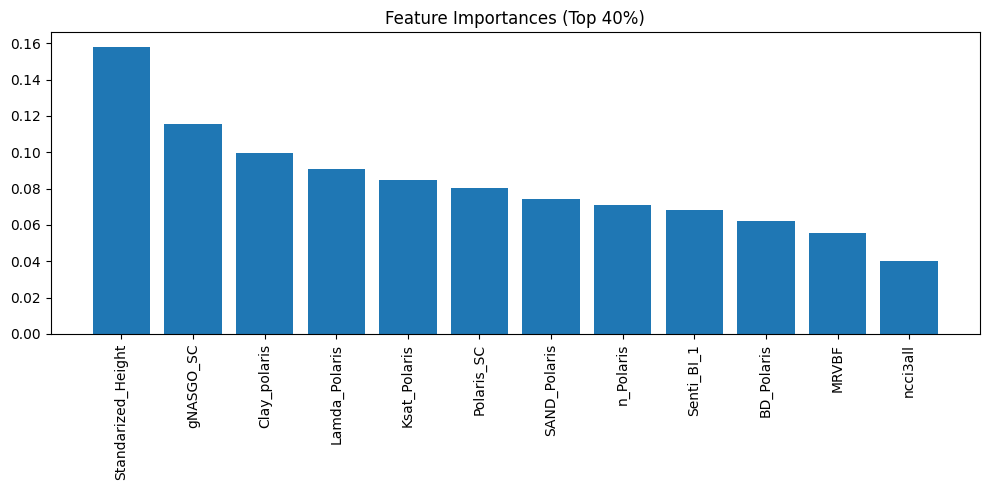

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)
selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_rf_model.pkl")
joblib.dump(scaler, "scaler.rf.pkl")
joblib.dump(list(selected_features), "selected_features.rf.pkl")

# === Step 8: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances (Top 40%)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.show()


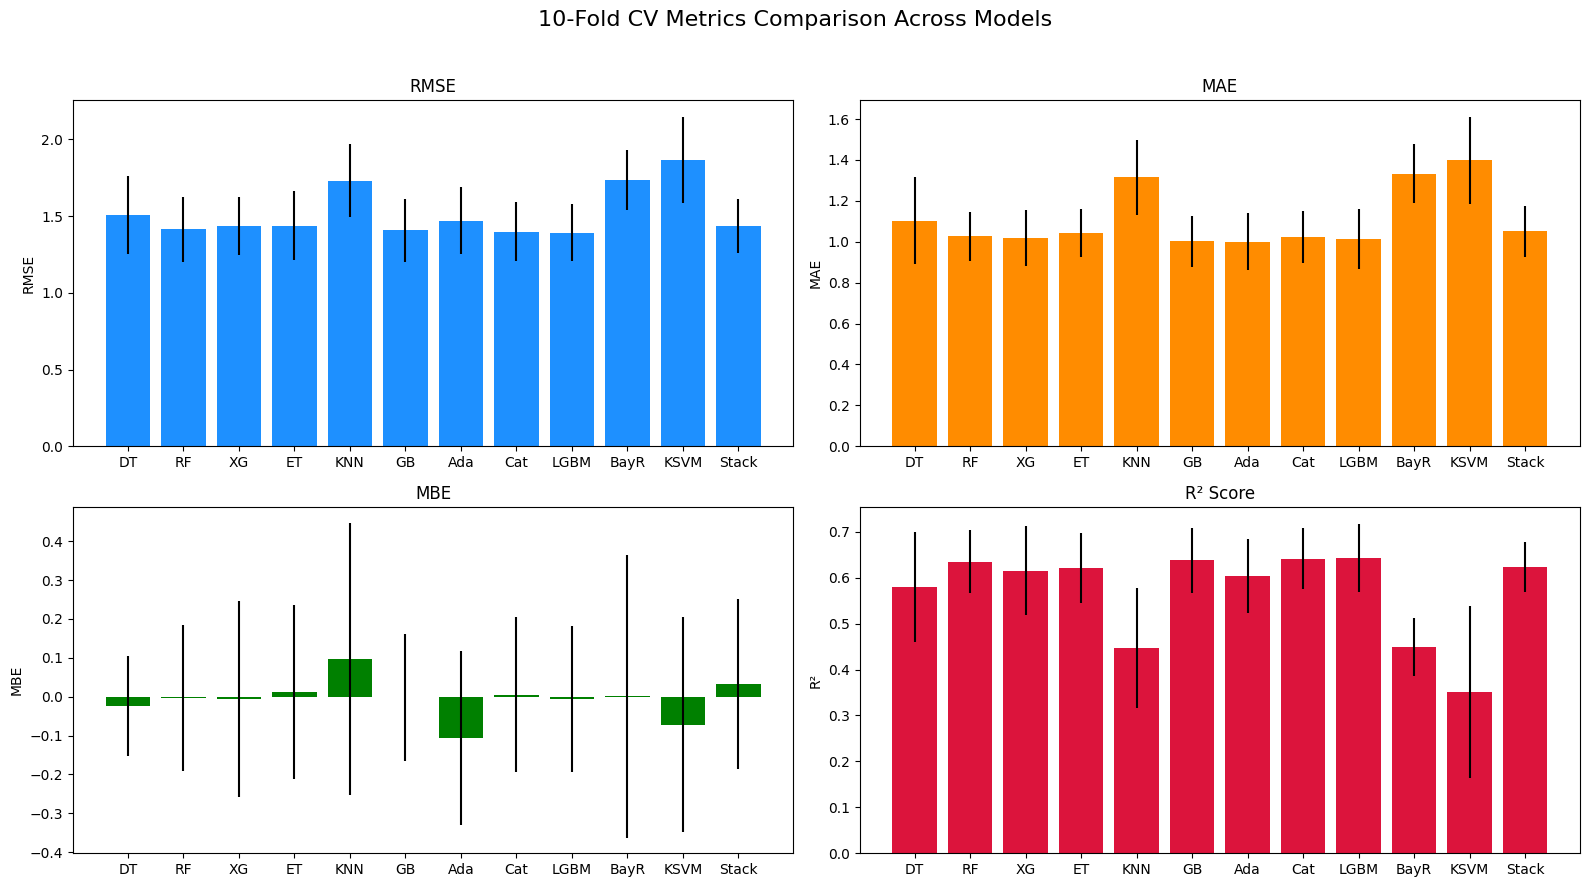

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Add your model-wise fold metrics ===
model_results = {

                 "DT": [
    {"MBE": -0.2298, "MAE": 1.1054, "RMSE": 1.5321, "R2": 0.6526},
    {"MBE": -0.0613, "MAE": 1.2849, "RMSE": 1.6906, "R2": 0.4526},
    {"MBE": 0.2428,  "MAE": 0.6169, "RMSE": 0.8272, "R2": 0.8020},
    {"MBE": 0.0402,  "MAE": 1.3129, "RMSE": 1.7011, "R2": 0.4203},
    {"MBE": -0.1035, "MAE": 1.2234, "RMSE": 1.6636, "R2": 0.5680},
    {"MBE": 0.0255,  "MAE": 0.9107, "RMSE": 1.3008, "R2": 0.6659},
    {"MBE": -0.0151, "MAE": 1.3256, "RMSE": 1.6764, "R2": 0.3997},
    {"MBE": 0.1039,  "MAE": 1.1023, "RMSE": 1.6370, "R2": 0.5688},
    {"MBE": -0.1628, "MAE": 0.9354, "RMSE": 1.4751, "R2": 0.6030},
    {"MBE": -0.0814, "MAE": 1.2015, "RMSE": 1.5536, "R2": 0.6603}
],
                 "RF": [
    {"MBE": -0.2355, "MAE": 1.1370, "RMSE": 1.6580, "R2": 0.5932},
    {"MBE": -0.1840, "MAE": 1.2013, "RMSE": 1.5862, "R2": 0.5182},
    {"MBE":  0.4082, "MAE": 0.7801, "RMSE": 0.9376, "R2": 0.7456},
    {"MBE":  0.0170, "MAE": 1.0641, "RMSE": 1.4918, "R2": 0.5542},
    {"MBE": -0.1088, "MAE": 1.1359, "RMSE": 1.5752, "R2": 0.6127},
    {"MBE":  0.2254, "MAE": 0.9053, "RMSE": 1.2592, "R2": 0.6869},
    {"MBE":  0.0868, "MAE": 1.0260, "RMSE": 1.3089, "R2": 0.6341},
    {"MBE": -0.0370, "MAE": 0.9530, "RMSE": 1.2924, "R2": 0.7312},
    {"MBE": -0.0513, "MAE": 0.9749, "RMSE": 1.3881, "R2": 0.6484},
    {"MBE": -0.1479, "MAE": 1.0877, "RMSE": 1.6412, "R2": 0.6210}
],


"XG": [
    {"MBE": -0.2181, "MAE": 0.9371, "RMSE": 1.4093, "R2": 0.7061},
    {"MBE": -0.1047, "MAE": 1.2490, "RMSE": 1.6434, "R2": 0.4828},
    {"MBE": 0.5881,  "MAE": 0.8320, "RMSE": 1.0851, "R2": 0.6593},
    {"MBE": 0.0126,  "MAE": 1.0664, "RMSE": 1.4771, "R2": 0.5630},
    {"MBE": -0.1696, "MAE": 1.0998, "RMSE": 1.5758, "R2": 0.6124},
    {"MBE": 0.2053,  "MAE": 0.8729, "RMSE": 1.1549, "R2": 0.7366},
    {"MBE": 0.2037,  "MAE": 1.2147, "RMSE": 1.6339, "R2": 0.4298},
    {"MBE": -0.1113, "MAE": 0.8529, "RMSE": 1.2884, "R2": 0.7329},
    {"MBE": -0.2389, "MAE": 1.0323, "RMSE": 1.4925, "R2": 0.5935},
    {"MBE": -0.2302, "MAE": 1.0182, "RMSE": 1.6042, "R2": 0.6378}
],


"ET": [
    {"MBE": -0.1541, "MAE": 1.1224, "RMSE": 1.5484, "R2": 0.6452},
    {"MBE": -0.1632, "MAE": 1.1972, "RMSE": 1.6450, "R2": 0.4818},
    {"MBE": 0.5096,  "MAE": 0.8621, "RMSE": 1.1103, "R2": 0.6433},
    {"MBE": 0.0243,  "MAE": 1.0014, "RMSE": 1.4078, "R2": 0.6030},
    {"MBE": -0.0729, "MAE": 1.2164, "RMSE": 1.7027, "R2": 0.5475},
    {"MBE": 0.3136,  "MAE": 0.9543, "RMSE": 1.2641, "R2": 0.6845},
    {"MBE": 0.0313,  "MAE": 1.0452, "RMSE": 1.2793, "R2": 0.6505},
    {"MBE": -0.1489, "MAE": 0.9348, "RMSE": 1.3695, "R2": 0.6982},
    {"MBE": 0.0294,  "MAE": 0.9269, "RMSE": 1.2209, "R2": 0.7280},
    {"MBE": -0.2503, "MAE": 1.1614, "RMSE": 1.8367, "R2": 0.5253}
],
   "KNN": [
    {"MBE": -0.2850, "MAE": 1.2071, "RMSE": 1.7166, "R2": 0.5639},
    {"MBE": -0.1406, "MAE": 1.6271, "RMSE": 2.0820, "R2": 0.1699},
    {"MBE": 0.6919,  "MAE": 0.9754, "RMSE": 1.2356, "R2": 0.5583},
    {"MBE": -0.1337, "MAE": 1.4044, "RMSE": 1.8635, "R2": 0.3044},
    {"MBE": -0.0197, "MAE": 1.3101, "RMSE": 1.7218, "R2": 0.5373},
    {"MBE": 0.8344,  "MAE": 1.4887, "RMSE": 1.8705, "R2": 0.3091},
    {"MBE": 0.0918,  "MAE": 1.0901, "RMSE": 1.4177, "R2": 0.5707},
    {"MBE": 0.0032,  "MAE": 1.3093, "RMSE": 1.7741, "R2": 0.4936},
    {"MBE": 0.0381,  "MAE": 1.2804, "RMSE": 1.6470, "R2": 0.5051},
    {"MBE": -0.1074, "MAE": 1.4568, "RMSE": 1.9702, "R2": 0.4537}
],
"GB": [
    {"MBE": -0.1646, "MAE": 1.0340, "RMSE": 1.4479, "R2": 0.6897},
    {"MBE": -0.0973, "MAE": 1.2014, "RMSE": 1.5887, "R2": 0.5166},
    {"MBE": 0.3490,  "MAE": 0.7537, "RMSE": 0.9470, "R2": 0.7405},
    {"MBE": 0.0231,  "MAE": 1.0046, "RMSE": 1.3949, "R2": 0.6103},
    {"MBE": -0.1628, "MAE": 1.1402, "RMSE": 1.6759, "R2": 0.5616},
    {"MBE": 0.1026,  "MAE": 0.8854, "RMSE": 1.2306, "R2": 0.7010},
    {"MBE": 0.1433,  "MAE": 1.0559, "RMSE": 1.4296, "R2": 0.5635},
    {"MBE": 0.0453,  "MAE": 0.9066, "RMSE": 1.3892, "R2": 0.6895},
    {"MBE": -0.0438, "MAE": 0.9437, "RMSE": 1.2993, "R2": 0.6920},
    {"MBE": -0.2104, "MAE": 1.0899, "RMSE": 1.6612, "R2": 0.6117}
],

                 "Ada": [
    {"MBE": -0.4580, "MAE": 1.0466, "RMSE": 1.5995, "R2": 0.6213},
    {"MBE": -0.2827, "MAE": 1.2495, "RMSE": 1.6834, "R2": 0.4573},
    {"MBE": 0.2797,  "MAE": 0.6996, "RMSE": 0.9069, "R2": 0.7620},
    {"MBE": 0.0229,  "MAE": 1.0770, "RMSE": 1.5100, "R2": 0.5433},
    {"MBE": -0.1173, "MAE": 1.1080, "RMSE": 1.7194, "R2": 0.5386},
    {"MBE": 0.2210,  "MAE": 0.8871, "RMSE": 1.3127, "R2": 0.6597},
    {"MBE": -0.0892, "MAE": 1.0209, "RMSE": 1.4486, "R2": 0.5518},
    {"MBE": -0.0969, "MAE": 1.0051, "RMSE": 1.4748, "R2": 0.6500},
    {"MBE": -0.1799, "MAE": 0.9079, "RMSE": 1.4521, "R2": 0.6152},
    {"MBE": -0.3677, "MAE": 0.9974, "RMSE": 1.6032, "R2": 0.6383}
],
                 "Cat": [
    {"MBE": -0.1667, "MAE": 1.0991, "RMSE": 1.5102, "R2": 0.6625},
    {"MBE": -0.1151, "MAE": 1.1769, "RMSE": 1.5493, "R2": 0.5403},
    {"MBE": 0.4865,  "MAE": 0.8100, "RMSE": 1.0453, "R2": 0.6839},
    {"MBE": 0.0818,  "MAE": 1.1124, "RMSE": 1.5050, "R2": 0.5463},
    {"MBE": -0.1697, "MAE": 1.1823, "RMSE": 1.6206, "R2": 0.5901},
    {"MBE": 0.1926,  "MAE": 0.8790, "RMSE": 1.1614, "R2": 0.7337},
    {"MBE": 0.0251,  "MAE": 1.0472, "RMSE": 1.3337, "R2": 0.6201},
    {"MBE": -0.0035, "MAE": 0.9053, "RMSE": 1.2970, "R2": 0.7293},
    {"MBE": -0.0696, "MAE": 0.9145, "RMSE": 1.2873, "R2": 0.6976},
    {"MBE": -0.2086, "MAE": 1.0969, "RMSE": 1.6581, "R2": 0.6131}
],
                 "LGBM": [
    {"MBE": -0.2052, "MAE": 0.9750, "RMSE": 1.4270, "R2": 0.6986},
    {"MBE": -0.0487, "MAE": 1.1434, "RMSE": 1.4918, "R2": 0.5738},
    {"MBE": 0.4104,  "MAE": 0.7171, "RMSE": 0.9503, "R2": 0.7387},
    {"MBE": 0.1235,  "MAE": 1.2344, "RMSE": 1.6144, "R2": 0.4779},
    {"MBE": -0.0376, "MAE": 1.1536, "RMSE": 1.5814, "R2": 0.6097},
    {"MBE": 0.1426,  "MAE": 0.9436, "RMSE": 1.2936, "R2": 0.6696},
    {"MBE": -0.0234, "MAE": 1.0998, "RMSE": 1.3551, "R2": 0.6078},
    {"MBE": -0.0517, "MAE": 0.8870, "RMSE": 1.3113, "R2": 0.7233},
    {"MBE": -0.0581, "MAE": 0.9263, "RMSE": 1.3210, "R2": 0.6816},
    {"MBE": -0.3063, "MAE": 1.0655, "RMSE": 1.5815, "R2": 0.6480}
],





"BayR": [
    {"MBE": -0.2568, "MAE": 1.3370, "RMSE": 1.8954, "R2": 0.4683},
    {"MBE": -0.4100, "MAE": 1.4333, "RMSE": 1.8775, "R2": 0.3249},
    {"MBE": 0.6848,  "MAE": 0.9939, "RMSE": 1.2384, "R2": 0.5562},
    {"MBE": -0.2239, "MAE": 1.2422, "RMSE": 1.7024, "R2": 0.4195},
    {"MBE": -0.2245, "MAE": 1.5489, "RMSE": 1.9422, "R2": 0.4112},
    {"MBE": 0.6627,  "MAE": 1.3702, "RMSE": 1.7287, "R2": 0.4099},
    {"MBE": 0.1332,  "MAE": 1.3346, "RMSE": 1.6232, "R2": 0.4372},
    {"MBE": -0.0962, "MAE": 1.3006, "RMSE": 1.6965, "R2": 0.5369},
    {"MBE": -0.0337, "MAE": 1.2929, "RMSE": 1.7517, "R2": 0.4401},
    {"MBE": -0.2242, "MAE": 1.4800, "RMSE": 1.9169, "R2": 0.4829}
],

"KSVM": [
    {"MBE": -0.2243, "MAE": 1.2330, "RMSE": 1.6647, "R2": 0.5899},
    {"MBE": -0.2815, "MAE": 1.6607, "RMSE": 2.1806, "R2": 0.0894},
    {"MBE": 0.5226,  "MAE": 0.9616, "RMSE": 1.2264, "R2": 0.5648},
    {"MBE": 0.0079,  "MAE": 1.7217, "RMSE": 2.2738, "R2": -0.0357},
    {"MBE": -0.3309, "MAE": 1.4788, "RMSE": 1.9295, "R2": 0.4189},
    {"MBE": 0.1998,  "MAE": 1.4374, "RMSE": 1.9174, "R2": 0.2740},
    {"MBE": -0.4562, "MAE": 1.1972, "RMSE": 1.6625, "R2": 0.4096},
    {"MBE": -0.1718, "MAE": 1.4950, "RMSE": 2.0344, "R2": 0.3341},
    {"MBE": -0.1082, "MAE": 1.3746, "RMSE": 1.8292, "R2": 0.3894},
    {"MBE": 0.1222,  "MAE": 1.4281, "RMSE": 1.9267, "R2": 0.4776}
],
"Stack": [
    {"MBE": -0.1921, "MAE": 1.0702, "RMSE": 1.5814, "R2": 0.6299},
    {"MBE": -0.0653, "MAE": 1.1721, "RMSE": 1.5246, "R2": 0.5549},
    {"MBE": 0.5301,  "MAE": 0.7885, "RMSE": 1.0018, "R2": 0.7096},
    {"MBE": 0.0837,  "MAE": 1.1553, "RMSE": 1.5312, "R2": 0.5303},
    {"MBE": -0.1453, "MAE": 1.2116, "RMSE": 1.6053, "R2": 0.5978},
    {"MBE": 0.3235,  "MAE": 1.0020, "RMSE": 1.3391, "R2": 0.6459},
    {"MBE": 0.0100,  "MAE": 1.0850, "RMSE": 1.4021, "R2": 0.5801},
    {"MBE": 0.0106,  "MAE": 0.9620, "RMSE": 1.3835, "R2": 0.6920},
    {"MBE": -0.0692, "MAE": 0.9353, "RMSE": 1.3808, "R2": 0.6521},
    {"MBE": -0.1685, "MAE": 1.1270, "RMSE": 1.6100, "R2": 0.6352}
]

    # Add other models here (Cat, ET, etc.)
}

# === STEP 2: Calculate averages and std devs ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Plot like original style ===
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=16)

axes[0, 0].bar(df.index, df['RMSE'], yerr=df['RMSE_std'], color='dodgerblue')
axes[0, 0].set_title("RMSE")
axes[0, 0].set_ylabel("RMSE")

axes[0, 1].bar(df.index, df['MAE'], yerr=df['MAE_std'], color='darkorange')
axes[0, 1].set_title("MAE")
axes[0, 1].set_ylabel("MAE")

axes[1, 0].bar(df.index, df['MBE'], yerr=df['MBE_std'], color='green')
axes[1, 0].set_title("MBE")
axes[1, 0].set_ylabel("MBE")

axes[1, 1].bar(df.index, df['R2'], yerr=df['R2_std'], color='crimson')
axes[1, 1].set_title("R² Score")
axes[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("foldwise_model_metrics_plot.png", dpi=300)
plt.show()


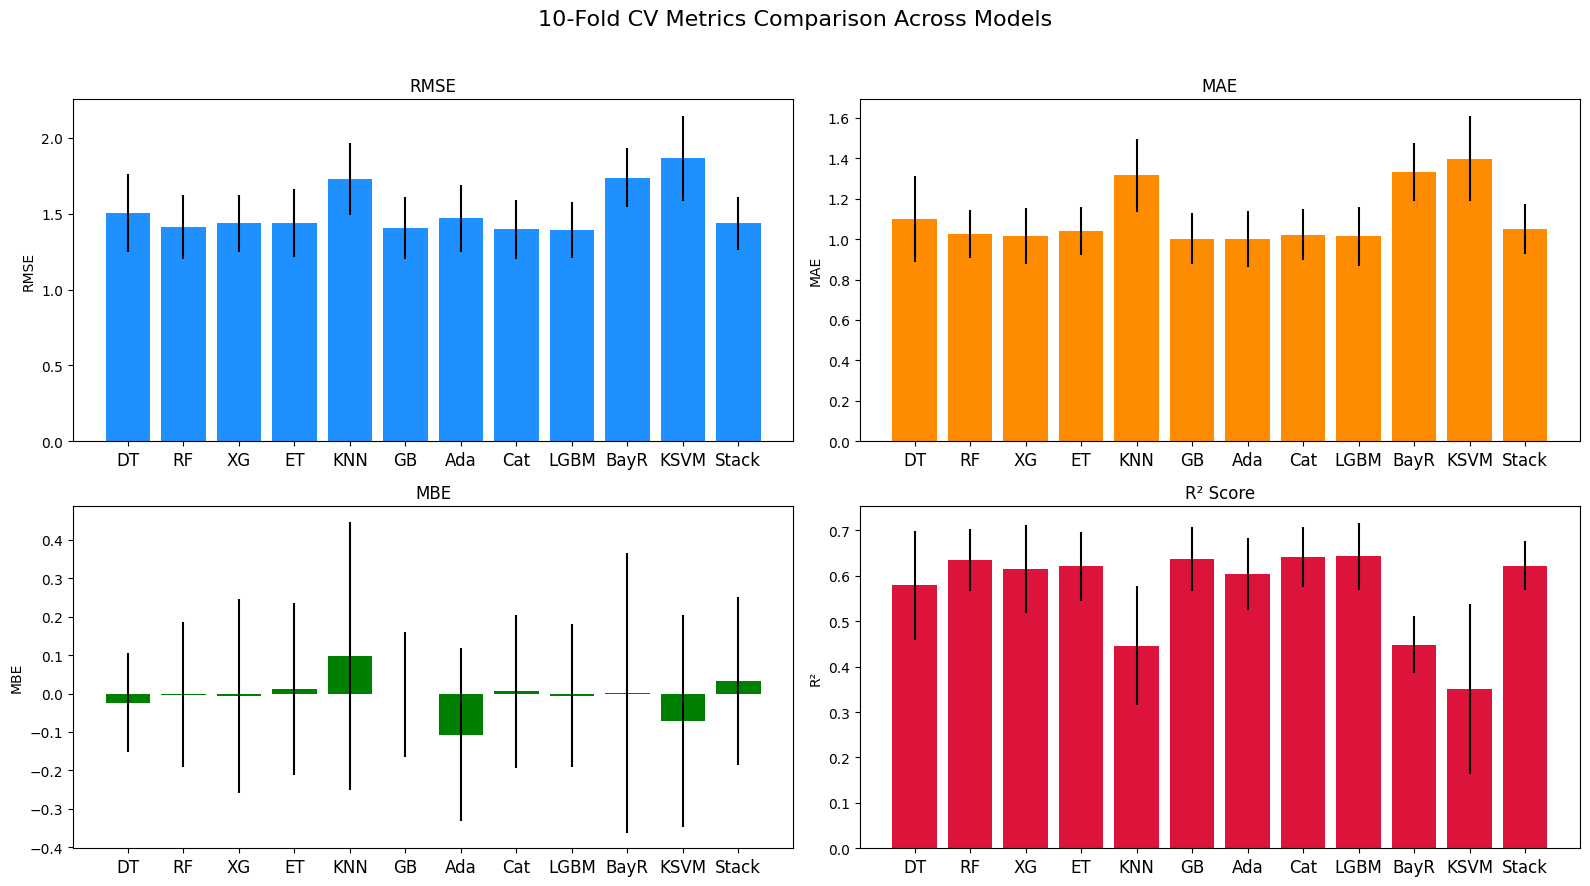

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Add your model-wise fold metrics ===
# (Assuming your `model_results` dictionary is already defined here)

# === STEP 2: Calculate averages and std devs ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Plot ===
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=16)

axes[0, 0].bar(df.index, df['RMSE'], yerr=df['RMSE_std'], color='dodgerblue')
axes[0, 0].set_title("RMSE")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].tick_params(axis='x', labelsize=12)  # Increase x-axis font size

axes[0, 1].bar(df.index, df['MAE'], yerr=df['MAE_std'], color='darkorange')
axes[0, 1].set_title("MAE")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].tick_params(axis='x', labelsize=12)

axes[1, 0].bar(df.index, df['MBE'], yerr=df['MBE_std'], color='green')
axes[1, 0].set_title("MBE")
axes[1, 0].set_ylabel("MBE")
axes[1, 0].tick_params(axis='x', labelsize=12)

axes[1, 1].bar(df.index, df['R2'], yerr=df['R2_std'], color='crimson')
axes[1, 1].set_title("R² Score")
axes[1, 1].set_ylabel("R²")
axes[1, 1].tick_params(axis='x', labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("foldwise_model_metrics_plot.png", dpi=300)
plt.show()


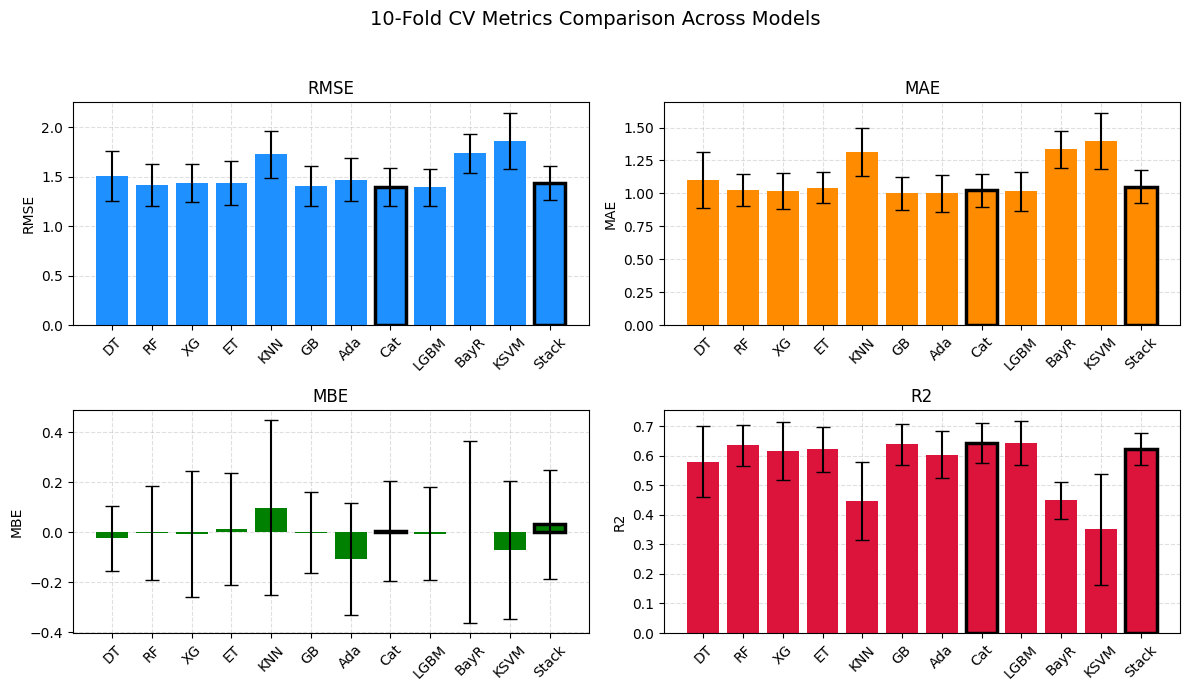

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Sample input — model_results must be defined ===
# (Assume model_results is already defined above this block)

# === STEP 2: Aggregate metrics ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Define best models to highlight ===
best_models = ["Cat", "Stack"]

# === STEP 4: Plot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 7))  # <-- Reduced from (16, 9)
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=14)  # Smaller title

metrics = ['RMSE', 'MAE', 'MBE', 'R2']
colors = ['dodgerblue', 'darkorange', 'green', 'crimson']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for i, metric in enumerate(metrics):
    row, col = positions[i]
    ax = axes[row, col]
    values = df[metric].values
    errors = df[f"{metric}_std"].values
    model_names = df.index.tolist()

    bars = ax.bar(model_names, values, color=colors[i], zorder=2)
    ax.errorbar(model_names, values, yerr=errors, fmt='none',
                ecolor='black', capsize=5, linewidth=1.5, zorder=3)

    for bar, label in zip(bars, model_names):
        if label in best_models:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("foldwise_model_metrics_smaller.png", dpi=300)
plt.show()


test

🔍 Features used for prediction:
 - Polaris_SC
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - SAND_Polaris
 - BD_Polaris
 - ncci3all
 - Ksat_Polaris
 - Lamda_Polaris
 - n_Polaris
 - Senti_BI_1
 - Standarized_Height

📊 Test Set Metrics (Random Forest):
MAE:  0.8162
RMSE: 1.0801
R²:   0.4845
MBE:  -0.0255


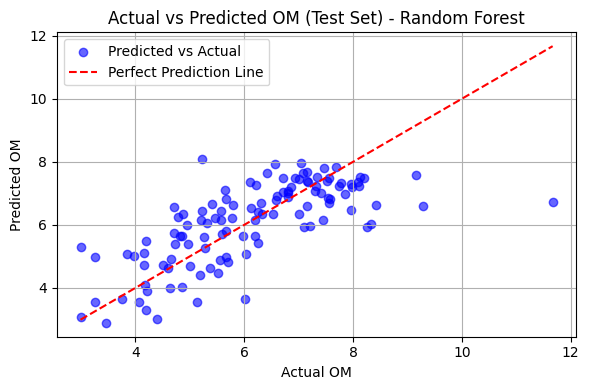

In [ ]:
# === TEST SCRIPT (Random Forest with MBE) ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_rf_model.pkl")  # Random Forest model
scaler = joblib.load("/content/scaler.rf.pkl")
selected_features = joblib.load("/content/selected_features.rf.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

print("\n📊 Test Set Metrics (Random Forest):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set) - Random Forest")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


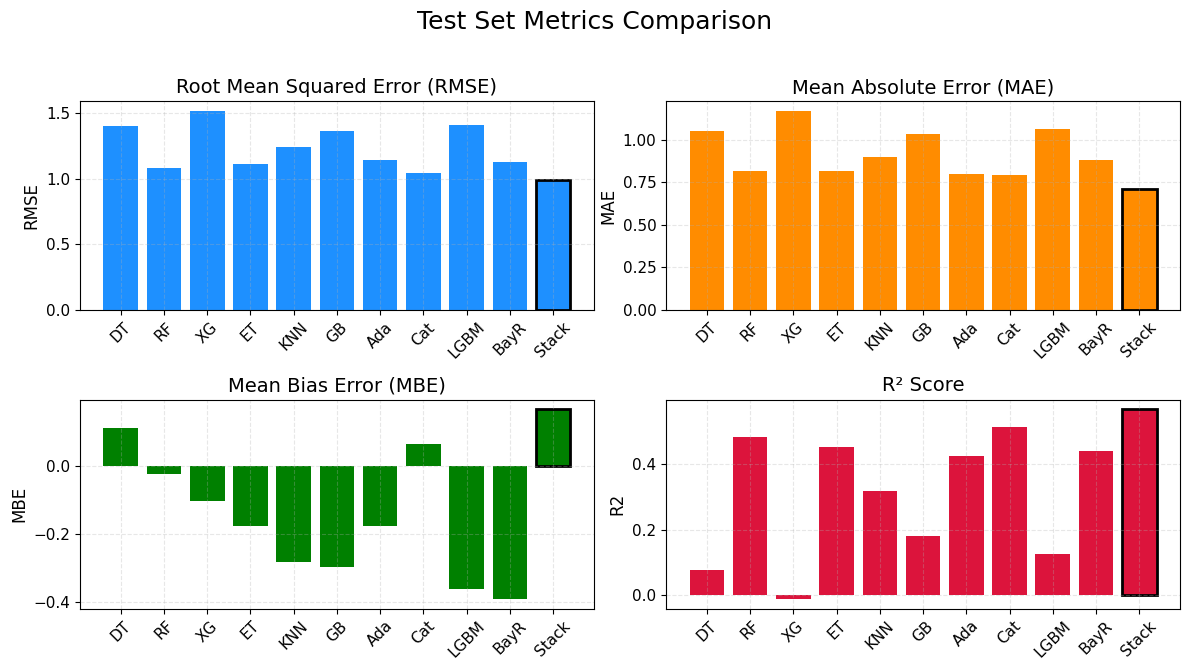

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# === STEP 1: Paste your test set metrics in readable text format ===
test_results_text = {
    "DT": """
        MAE:  1.0496
        RMSE: 1.4012
        R²:   0.0757
        MBE:  0.1098
    """,
    "RF": """
        MAE:  0.8162
        RMSE: 1.0801
        R²:   0.4845
        MBE: -0.0255
    """,
    "XG": """
        MAE:  1.1663
        RMSE: 1.5141
        R²:   -0.0129
        MBE:  -0.104
    """,
    "ET": """
        MAE:  0.8136
        RMSE: 1.1123
        R²:   0.4534
        MBE: -0.1762
    """,
    "KNN": """
        MAE:  0.8985
        RMSE: 1.2420
        R²:   0.3185
        MBE: -0.2807
    """,
    "GB": """
        MAE:  1.0342
        RMSE: 1.3623
        R²:   0.1801
        MBE: -0.2955
    """,
    "Ada": """
        MAE:  0.7990
        RMSE: 1.1414
        R²:   0.4244
        MBE: -0.1754
    """,
    "Cat": """
        MAE:  0.7917
        RMSE: 1.0466
        R²:   0.5161
        MBE:  0.0633
    """,
    "LGBM": """
        MAE:  1.0609
        RMSE: 1.4064
        R²:   0.1261
        MBE: -0.3606
    """,
    "BayR": """
        MAE:  0.8810
        RMSE: 1.1255
        R²:   0.4403
        MBE: -0.3907
    """,
    "Stack": """
    MAE:  0.711
    RMSE: 0.988
    R²:   0.569
    MBE:  0.165
"""
,
}

# === STEP 2: Parse metrics ===
def parse_metrics_block(text):
    metrics = {}
    for line in text.strip().splitlines():
        match = re.match(r'([A-Za-z²]+):\s+([-+]?\d*\.\d+|\d+)', line.strip())
        if match:
            key = match.group(1).replace('R²', 'R2')
            metrics[key] = float(match.group(2))
    return metrics

parsed_results = {model: parse_metrics_block(text) for model, text in test_results_text.items()}

# === STEP 3: Convert to DataFrame with custom order ===
df = pd.DataFrame(parsed_results).T
df.index.name = "Model"
custom_order = ["DT", "RF", "XG", "ET", "KNN", "GB", "Ada", "Cat", "LGBM", "BayR", "Stack"]
df = df.loc[custom_order]

# === STEP 4: Highlight the best model based on R² ===
highlight_model = df['R2'].idxmax()

# === STEP 5: Plotting ===
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Test Set Metrics Comparison", fontsize=18, y=0.95)

def plot_metric(ax, metric, color, title):
    bars = ax.bar(df.index, df[metric], color=color)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', labelsize=11, labelrotation=45)
    ax.tick_params(axis='y', labelsize=11)

    for bar, label in zip(bars, df.index):
        if label == highlight_model:
            bar.set_edgecolor("black")
            bar.set_linewidth(2)

    ax.grid(True, linestyle='--', alpha=0.3)

plot_metric(axes[0, 0], 'RMSE', 'dodgerblue', "Root Mean Squared Error (RMSE)")
plot_metric(axes[0, 1], 'MAE', 'darkorange', "Mean Absolute Error (MAE)")
plot_metric(axes[1, 0], 'MBE', 'green', "Mean Bias Error (MBE)")
plot_metric(axes[1, 1], 'R2', 'crimson', "R² Score")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("test_metrics_summary_ordered_clean.png", dpi=300)
plt.show()


  et

Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Best Hyperparameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.2403, MAE: 1.2200, RMSE: 1.6470, R²: 0.5985
Fold 2 → MBE: -0.2446, MAE: 1.3107, RMSE: 1.8195, R²: 0.3660
Fold 3 → MBE: 0.4790, MAE: 0.8362, RMSE: 1.0550, R²: 0.6779
Fold 4 → MBE: 0.0161, MAE: 1.1063, RMSE: 1.5867, R²: 0.4957
Fold 5 → MBE: -0.1761, MAE: 1.2466, RMSE: 1.7566, R²: 0.5184
Fold 6 → MBE: 0.4567, MAE: 1.0147, RMSE: 1.4073, R²: 0.6090
Fold 7 → MBE: 0.0551, MAE: 1.0475, RMSE: 1.3114, R²: 0.6327
Fold 8 → MBE: -0.1380, MAE: 1.0263, RMSE: 1.4483, R²: 0.6625
Fold 9 → MBE: 0.0034, MAE: 0.9578, RMSE: 1.2276, R²: 0.7250
Fold 10 → MBE: -0.2815, MAE: 1.2550, RMSE: 1.9420, R²: 0.4693

📌 Average 10-Fold Train Metrics:
MBE:  -0.0070
MAE:  1.1021
RMSE: 1.5201
R²:   0.5755


/tmp/ipython-input-38-3270117882.py:105: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


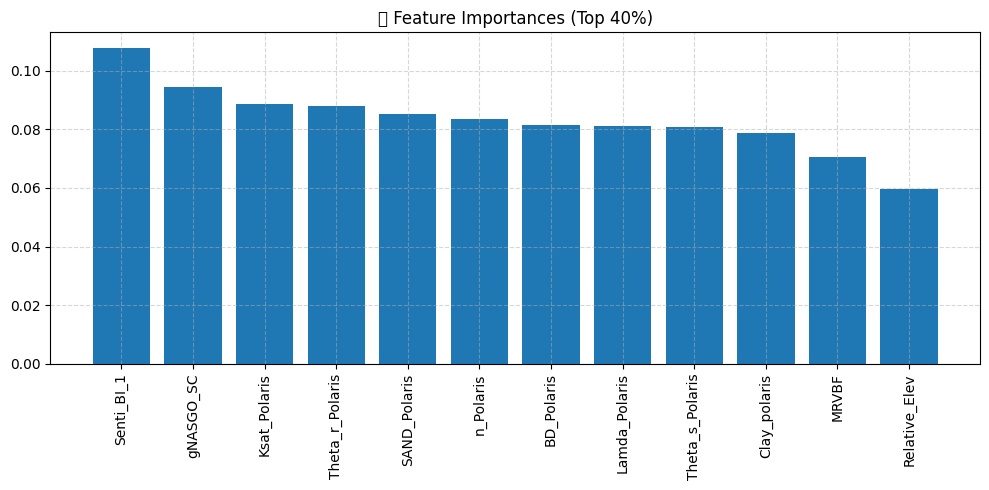

In [ ]:
# === All-in-One Training Script with ExtraTreesRegressor ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Standarized_Height', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=ExtraTreesRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Print best hyperparameters ===
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Train Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Model Artifacts ===
joblib.dump(best_model, "best_et_model.pkl")
joblib.dump(scaler, "scaler.et.pkl")
joblib.dump(list(selected_features), "selected_features.et.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("📈 Feature Importances (Top 40%)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.show()


TEST_ET

🔍 Features used for prediction:
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - SAND_Polaris
 - BD_Polaris
 - Ksat_Polaris
 - Lamda_Polaris
 - n_Polaris
 - Theta_r_Polaris
 - Theta_s_Polaris
 - Senti_BI_1
 - Relative_Elev

📊 Test Set Metrics:
MAE:  0.8238
RMSE: 1.1276
R²:   0.4382
MBE:  -0.4111


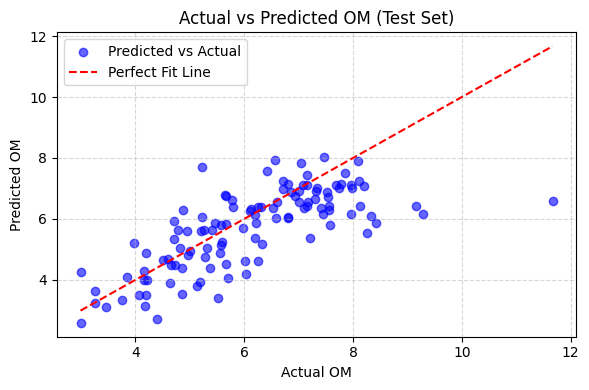

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_et_model.pkl")
scaler = joblib.load("scaler.et.pkl")
selected_features = joblib.load("selected_features.et.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MBE:  {np.mean(y_pred - y_test):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Sample metric values (replace with your actual results) ===
models = ['DT', 'ET', 'RF', 'GB', 'XGB', 'BR', 'MLP', 'CNN', 'SR']

rmse = [1250, 1150, 1100, 1130, 1080, 1200, 1300, 1290, 1050]
mae  = [900, 800, 810, 805, 790, 950, 920, 940, 770]
mbe  = [5, 25, 22, 27, 30, 20, 35, 38, 28]
r2   = [0.78, 0.84, 0.82, 0.81, 0.85, 0.79, 0.75, 0.74, 0.88]

# === Simulated error bars (std devs); replace with actual ones ===
rmse_err = [100, 80, 75, 90, 70, 95, 130, 125, 60]
mae_err  = [50, 40, 45, 42, 38, 55, 50, 53, 35]
mbe_err  = [4, 5, 6, 4, 5, 5, 7, 6, 5]
r2_err   = [0.05] * len(models)

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('📊 Performance Metrics Comparison Across Regression Models', fontsize=16)

# — RMSE —
axs[0, 0].bar(models, rmse, color='dodgerblue', yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

# — MAE —
axs[0, 1].bar(models, mae, color='darkorange', yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

# — MBE —
axs[1, 0].bar(models, mbe, color='green', yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

# — R² —
axs[1, 1].bar(models, r2, color='firebrick', yerr=r2_err, capsize=5)
axs[1, 1].set_title("R²")
axs[1, 1].set_ylabel("R² Score")

# === Highlight best model per metric ===
for ax, values, is_higher_better in zip(
    axs.flat, [rmse, mae, mbe, r2], [False, False, False, True]
):
    best_idx = np.argmax(values) if is_higher_better else np.argmin(values)
    ax.bar(models[best_idx], values[best_idx],
           edgecolor='black', linewidth=2.5, fill=False)

# === Final layout adjustments ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM']

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263, 1.178]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550, -0.052]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374, 0.465]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941, 1.362]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899, 1.94]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143, 0.938]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458, 1.35]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604, -0.321]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, 0.428]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626, 0.17]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, 0.63]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Define best model based on highest R² score
best_model_idx = np.argmax(r2)  # Get index of the best model based on R² score

# Set homogeneous colors for each metric across all models
colors_rmse = ['cornflowerblue'] * len(models)
colors_mae = ['darkorange'] * len(models)
colors_mbe = ['mediumseagreen'] * len(models)
colors_r2 = ['crimson'] * len(models)

# Highlight the best model
colors_rmse[best_model_idx] = 'limegreen'
colors_mae[best_model_idx] = 'limegreen'
colors_mbe[best_model_idx] = 'limegreen'
colors_r2[best_model_idx] = 'limegreen'

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

# RMSE
axs[0, 0].bar(models, rmse, color=colors_rmse, yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (%)")

# MAE
axs[0, 1].bar(models, mae, color=colors_mae, yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (%)")

# MBE
axs[1, 0].bar(models, mbe, color=colors_mbe, yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (%)")

# R²
axs[1, 1].bar(models, r2, color=colors_r2, yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Best Model Metrics Summary
print("\n📌 Best Model Metrics Summary (10-Fold CV):")
print(f"Best Model: {models[best_model_idx]}")
print(f"MBE:  Mean = {mbe[best_model_idx]:.4f}, Min = {mbe_min[best_model_idx]:.4f}, Max = {mbe_max[best_model_idx]:.4f}")
print(f"MAE:  Mean = {mae[best_model_idx]:.4f}, Min = {mae_min[best_model_idx]:.4f}, Max = {mae_max[best_model_idx]:.4f}")
print(f"RMSE: Mean = {rmse[best_model_idx]:.4f}, Min = {rmse_min[best_model_idx]:.4f}, Max = {rmse_max[best_model_idx]:.4f}")
print(f"R²:   Mean = {r2[best_model_idx]:.4f}, Min = {r2_min[best_model_idx]:.4f}, Max = {r2_max[best_model_idx]:.4f}")


KNN

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Senti_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base KNN ===
knn_base = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_base.fit(X_scaled, y)
perm_importance = permutation_importance(knn_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=10, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_knn = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_knn.fit(X_t, y_t)
    y_pred = best_knn.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.knn.pkl")
joblib.dump(selected_features, "selected_features.knn.pkl")


📌 Selected Features (12 of 31):
 - MRVBF
 - Aspect
 - gNASGO_SC
 - Convexity
 - Mid_Slope_Position
 - Planet_BI_1
 - Convergence_Index
 - Profile_curva
 - PH_Polaris
 - Tang_curva
 - Alpha_Polaris
 - Slope

✅ Best Hyperparameters:
{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'uniform'}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1687, MAE: 1.4212, RMSE: 1.8803, R²: 0.3833
Fold 2 → MBE: -0.4145, MAE: 1.7493, RMSE: 2.3528, R²: 0.1603
Fold 3 → MBE: 0.4526, MAE: 1.3781, RMSE: 1.8219, R²: 0.2216
Fold 4 → MBE: 0.2064, MAE: 1.5060, RMSE: 1.9203, R²: 0.2348
Fold 5 → MBE: 0.1795, MAE: 1.2494, RMSE: 1.6532, R²: 0.5229
Fold 6 → MBE: 0.6739, MAE: 1.3936, RMSE: 1.7941, R²: 0.2445
Fold 7 → MBE: 0.1372, MAE: 1.1703, RMSE: 1.5107, R²: 0.6197
Fold 8 → MBE: -0.1094, MAE: 1.3197, RMSE: 1.7140, R²: 0.5313
Fold 9 → MBE: 0.3075, MAE: 1.4625, RMSE: 1.9195, R²: 0.3692
Fold 10 → MBE: -0.0170, MAE: 1.5316, RMSE: 2.0403, R²: 0.4100

📌 Average 10-Fold Metrics:
MBE:  0.1248
MAE:  1.4182
RMSE: 1.8607
R²:   0.369

['selected_features.knn.pkl']

TEST KNN

🔍 Features used for prediction:
 - MRVBF
 - Aspect
 - gNASGO_SC
 - Convexity
 - Mid_Slope_Position
 - Planet_BI_1
 - Convergence_Index
 - Profile_curva
 - PH_Polaris
 - Tang_curva
 - Alpha_Polaris
 - Slope

📊 Test Set Metrics:
MAE:  1.4108
RMSE: 1.7488
R²:   -0.3512
MBE:  -1.0365


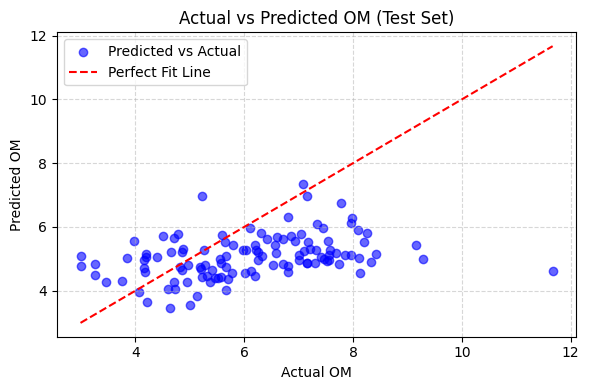

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_knn_model.pkl")
scaler = joblib.load("scaler.knn.pkl")
selected_features = joblib.load("selected_features.knn.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MBE:  {np.mean(y_pred - y_test):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


GB

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Standarized_Height' ,'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base GB ===
gb_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_base.fit(X_scaled, y)
perm_importance = permutation_importance(gb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_gb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_gb.fit(X_t, y_t)
    y_pred = best_gb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_gb, "best_gb_model.pkl")
joblib.dump(scaler, "scaler_gb.pkl")
joblib.dump(selected_features, "selected_features_gb.pkl")


📌 Selected Features (12 of 31):
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Ksat_Polaris
 - Clay_polaris
 - n_Polaris
 - Lamda_Polaris
 - pctearthmc
 - BD_Polaris
 - Relative_Elev
 - TWI
 - Theta_s_Polaris

✅ Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1812, MAE: 1.0565, RMSE: 1.4829, R²: 0.6745
Fold 2 → MBE: -0.0130, MAE: 1.2713, RMSE: 1.6387, R²: 0.4857
Fold 3 → MBE: 0.4020, MAE: 0.8337, RMSE: 1.0950, R²: 0.6530
Fold 4 → MBE: 0.0028, MAE: 1.1282, RMSE: 1.6271, R²: 0.4697
Fold 5 → MBE: -0.2674, MAE: 1.1120, RMSE: 1.6417, R²: 0.5793
Fold 6 → MBE: 0.0948, MAE: 0.8812, RMSE: 1.1470, R²: 0.7402
Fold 7 → MBE: 0.0296, MAE: 0.9455, RMSE: 1.2431, R²: 0.6699
Fold 8 → MBE: -0.1216, MAE: 0.9118, RMSE: 1.3464, R²: 0.7083
Fold 9 → MBE: -0.0562, MAE: 0.8367, RMSE: 1.1678, R²: 0.7511
Fold 10 → MBE: -0.1696, MAE: 1.0867, RMSE: 1.6166, R²: 0.6322

📌 Average 10-Fold M

['selected_features_gb.pkl']

TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Ksat_Polaris
 - Clay_polaris
 - n_Polaris
 - Lamda_Polaris
 - pctearthmc
 - BD_Polaris
 - Relative_Elev
 - TWI
 - Theta_s_Polaris

📊 Test Set Metrics (Gradient Boosting):
MAE:  1.0000
RMSE: 1.3265
R²:   0.2225
MBE:  -0.3566


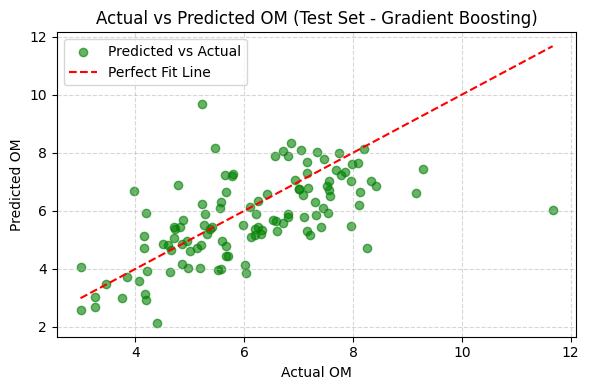

In [ ]:
# === TEST SCRIPT (Gradient Boosting with MBE) ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_gb_model.pkl")         # 👈 GB model file
scaler = joblib.load("/content/scaler_gb.pkl")
selected_features = joblib.load("/content/selected_features_gb.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)  # Mean Bias Error

print("\n📊 Test Set Metrics (Gradient Boosting):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set - Gradient Boosting)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
errors = y_test - y_pred
plt.figure(figsize=(6, 3))
plt.hist(errors, bins=30, color='orange', edgecolor='black')
plt.title("Prediction Errors Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
plt.scatter(y_test, errors, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Actual OM")
plt.ylabel("Error")
plt.grid(True)
plt.show()


In [ ]:
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv("gb_test_predictions.csv", index=False)


DT

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base DT ===
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_scaled, y)
perm_importance = permutation_importance(dt_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_dt = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_dt.fit(X_t, y_t)
    y_pred = best_dt.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_dt, "best_dt_model.pkl")
joblib.dump(scaler, "scaler_dt.pkl")
joblib.dump(selected_features, "selected_features_dt.pkl")


📌 Selected Features (12 of 31):
 - Standarized_Height
 - Clay_polaris
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Slope_Height
 - Mid_Slope_Position
 - PH_Polaris
 - Theta_r_Polaris
 - Convexity
 - ncci3all
 - SAND_Polaris

✅ Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.2298, MAE: 1.1054, RMSE: 1.5321, R²: 0.6526
Fold 2 → MBE: -0.0613, MAE: 1.2849, RMSE: 1.6906, R²: 0.4526
Fold 3 → MBE: 0.2428, MAE: 0.6169, RMSE: 0.8272, R²: 0.8020
Fold 4 → MBE: 0.0402, MAE: 1.3129, RMSE: 1.7011, R²: 0.4203
Fold 5 → MBE: -0.1035, MAE: 1.2234, RMSE: 1.6636, R²: 0.5680
Fold 6 → MBE: 0.0255, MAE: 0.9107, RMSE: 1.3008, R²: 0.6659
Fold 7 → MBE: -0.0151, MAE: 1.3256, RMSE: 1.6764, R²: 0.3997
Fold 8 → MBE: 0.1039, MAE: 1.1023, RMSE: 1.6370, R²: 0.5688
Fold 9 → MBE: -0.1628, MAE: 0.9354, RMSE: 1.4751, R²: 0.6030
Fold 10 → MBE: -0.0814, MAE: 1.2015, RMSE: 1.5536, R²: 0.6603

📌 Average 10-Fold Metrics:
MBE:  -0.0241
MAE:  1.1019
RMSE: 1.50

['selected_features_dt.pkl']

TEST DT

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load Test Data ===
test_df = pd.read_csv("/content/Antho_Test_,11,21_field.csv")

# === Step 2: Load Saved Artifacts ===
model = joblib.load("best_dt_model.pkl")
scaler = joblib.load("scaler_dt.pkl")
selected_features = joblib.load("selected_features_dt.pkl")

# === Step 3: Clean and Prepare Test Data ===
test_df = test_df[test_df['OM'] <= 12].dropna(subset=['OM'])
X_test_raw = test_df[selected_features].copy()
y_test = test_df['OM']

# Drop rows with NaNs in selected features
X_test_raw = X_test_raw.dropna()
y_test = y_test.loc[X_test_raw.index]

# === Step 4: Scale the Selected Features ===
X_test_scaled = scaler.transform(X_test_raw)

# === Step 5: Predict and Evaluate ===
y_pred = model.predict(X_test_scaled)

mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === Step 6: Print Final Test Metrics ===
print("\n✅ Test Set Metrics (Decision Tree):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")



✅ Test Set Metrics (Decision Tree):
MAE:  1.0496
RMSE: 1.4012
R²:   0.0757
MBE:  0.1098


XGBOOST

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long','Standarized_Height', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Handle non-numeric values in X ===
# Convert all columns to numeric, coercing errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')
# Drop rows with any NaN values introduced by coercion
X = X.dropna()
# Align y with the cleaned X
y = y.loc[X.index]


# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base XGBoost ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_xgb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_xgb.fit(X_t, y_t)
    y_pred = best_xgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler_xgb.pkl")
joblib.dump(selected_features, "selected_features_xgb.pkl")

📌 Selected Features (12 of 31):
 - Senti_BI_1
 - gNASGO_SC
 - Lamda_Polaris
 - MRVBF
 - Clay_polaris
 - pctearthmc
 - TWI
 - Ksat_Polaris
 - PH_Polaris
 - Relative_Elev
 - Polaris_SC
 - HB_Polaris

✅ Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1356, MAE: 1.1174, RMSE: 1.6182, R²: 0.6125
Fold 2 → MBE: -0.0938, MAE: 1.2534, RMSE: 1.7241, R²: 0.4307
Fold 3 → MBE: 0.6216, MAE: 0.9026, RMSE: 1.1550, R²: 0.6140
Fold 4 → MBE: -0.1808, MAE: 1.0717, RMSE: 1.5416, R²: 0.5240
Fold 5 → MBE: -0.2823, MAE: 1.0691, RMSE: 1.5083, R²: 0.6449
Fold 6 → MBE: 0.2408, MAE: 0.7829, RMSE: 1.0318, R²: 0.7898
Fold 7 → MBE: 0.0663, MAE: 0.9515, RMSE: 1.3086, R²: 0.6343
Fold 8 → MBE: -0.1222, MAE: 1.0068, RMSE: 1.5019, R²: 0.6370
Fold 9 → MBE: 0.0907, MAE: 0.9767, RMSE: 1.3689, R²: 0.6581
Fold 10 → MBE: -0.1733, MAE: 1.1266, RMSE: 1.6145, R²: 0.6332

📌 Average 10-Fold Metr

['selected_features_xgb.pkl']

/tmp/ipython-input-43-2278216271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()


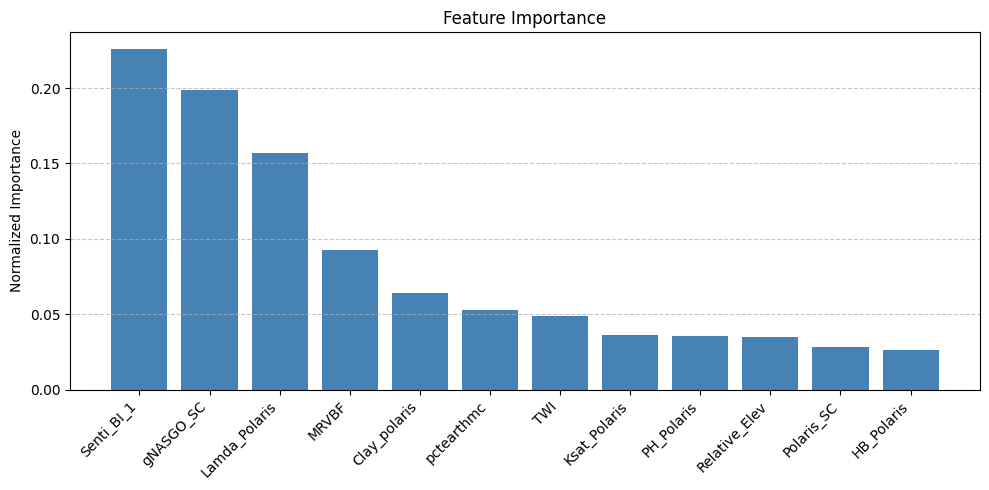

In [ ]:
# === Step 10: Plot Feature Importance ===
importance_df = importance_df[importance_df['Feature'].isin(selected_features)]
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Normalized Importance")
plt.title("Feature Importance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# === Step 11: Model Performance vs. Number of Selected Features ===
r2_scores = []
feature_counts = []

print("\n📈 Evaluating performance vs number of features:")
for k in range(1, len(importance_df) + 1):
    top_k_features = importance_df['Feature'].iloc[:k].tolist()
    X_k = X[top_k_features].fillna(0)

    # Scale
    X_k_scaled = scaler.fit_transform(X_k)

    # 10-fold CV for each k
    r2_list = []
    for train_idx, val_idx in kf.split(X_k_scaled):
        X_t, X_v = X_k_scaled[train_idx], X_k_scaled[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        best_xgb.fit(X_t, y_t)
        y_pred = best_xgb.predict(X_v)
        r2 = r2_score(y_v, y_pred)
        r2_list.append(r2)

    avg_r2 = np.mean(r2_list)
    r2_scores.append(avg_r2)
    feature_counts.append(k)
    print(f"{k} features → Avg R²: {avg_r2:.4f}")

# === Plot: R² vs Feature Count ===
plt.figure(figsize=(8, 5))
plt.plot(feature_counts, r2_scores, marker='o', linestyle='-', color='royalblue')
plt.title("Model R² vs Selected Features")
plt.xlabel("Number of Features")
plt.ylabel("Average R² (10-Fold CV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import shap

# === Step 10: SHAP Beeswarm Plot for Selected Features ===

# Load model and selected features
model = joblib.load("best_xgb_model.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# Prepare original unscaled selected features DataFrame
X_selected_df = X[selected_features]

# Fit the model again on full data (unscaled) to match SHAP expectations
model.fit(X_selected_df, y)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# Plot SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm_selected_features.png", dpi=300, bbox_inches='tight')
plt.show()


https://planetarycomputer.microsoft.com/dataset/gnatsgo-rasters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# === Step 1: Load & Filter Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long','Relative_Elev', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

# === Step 3: Fit Base Model & Get Permutation Importances ===
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)
xgb.fit(X_scaled, y)
perm = permutation_importance(xgb, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)
sorted_indices = np.argsort(perm.importances_mean)[::-1]

# === Step 4: Evaluate R² vs % of Selected Features ===
percentages = list(range(10, 101, 10))
r2_scores = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for pct in percentages:
    k = int(len(feature_names) * pct / 100)
    top_k_indices = sorted_indices[:k]
    top_k_features = [feature_names[i] for i in top_k_indices]
    X_k = X[top_k_features]
    X_k_scaled = scaler.fit_transform(X_k)

    fold_r2 = []
    for train_idx, val_idx in kf.split(X_k_scaled):
        X_train, X_val = X_k_scaled[train_idx], X_k_scaled[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        fold_r2.append(r2_score(y_val, preds))

    avg_r2 = np.mean(fold_r2)
    r2_scores.append(avg_r2)
    print(f"{pct}% features → R²: {avg_r2:.4f}")

# === Step 5: Plot ===
plt.figure(figsize=(8, 6))
plt.plot(percentages, r2_scores, marker='o')
plt.title("Model R² vs Percentage of Selected Features")
plt.xlabel("Percentage of Top Features Used")
plt.ylabel("Average R² (10-fold CV)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("r2_vs_percent_selected_features.png", dpi=300)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='pctearthmc', y='OM', alpha=0.6)
plt.title("Relationship Between pctearthmc and OM in Farmland Samples")
plt.xlabel("pctearthmc")
plt.ylabel("OM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import shap
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load model and artifacts
model = joblib.load("best_xgb_model.pkl")
scaler = joblib.load("scaler_xgb.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# Load dataset
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

# Prepare data
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
X = X[selected_features]
X_scaled = pd.DataFrame(scaler.transform(X), columns=selected_features)

# SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X_scaled)

# Plotting function
def plot_shap_vs_feature(feature_name):
    idx = selected_features.index(feature_name)
    plt.figure(figsize=(6, 4))
    plt.scatter(X[feature_name], shap_values.values[:, idx], alpha=0.6, c=X[feature_name], cmap="coolwarm")
    plt.colorbar(label=f"{feature_name} Value")
    plt.xlabel(feature_name)
    plt.ylabel("SHAP Value")
    plt.title(f"SHAP Value vs {feature_name} (Impact on OM Prediction)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"shap_vs_{feature_name}.png", dpi=300)
    plt.show()

# Run for each feature
features_to_plot = [
    "gNASGO_SC", "Lamda_Polaris", "Senti_BI_1", "MRVBF", "Clay_polaris",
     "pctearthmc", "Ksat_Polaris", "TWI", "Standardized_Height",
    'SILT_Polaris', "ncci3all"
]

for feature in features_to_plot:
    plot_shap_vs_feature(feature)


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base XGBoost ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_xgb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_xgb.fit(X_t, y_t)
    y_pred = best_xgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler_xgb.pkl")
joblib.dump(selected_features, "selected_features_xgb.pkl")


TEST_XGBOOST

🔍 Features used for prediction:
 - Senti_BI_1
 - gNASGO_SC
 - Lamda_Polaris
 - MRVBF
 - Clay_polaris
 - pctearthmc
 - TWI
 - Ksat_Polaris
 - PH_Polaris
 - Relative_Elev
 - Polaris_SC
 - HB_Polaris

📊 Test Set Metrics (XGBoost):
MAE:  0.9621
RMSE: 1.2697
R²:   0.2878
MBE:  -0.2494


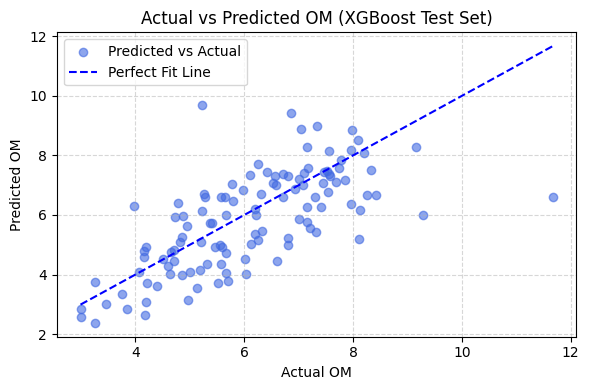

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for XGBoost ===
model = joblib.load("best_xgb_model.pkl")       # ✅ XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati' ,'Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)  # ⬅️ MBE

print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Standarized_Height
 - gNASGO_SC
 - Senti_BI_1
 - Lamda_Polaris
 - MRVBF
 - Ksat_Polaris
 - n_Polaris
 - Clay_polaris
 - PH_Polaris
 - TWI
 - ncci3all
 - Polaris_SC

📊 Test Set Metrics (XGBoost):
MAE:  1.1663
RMSE: 1.5141
R²:   -0.0129


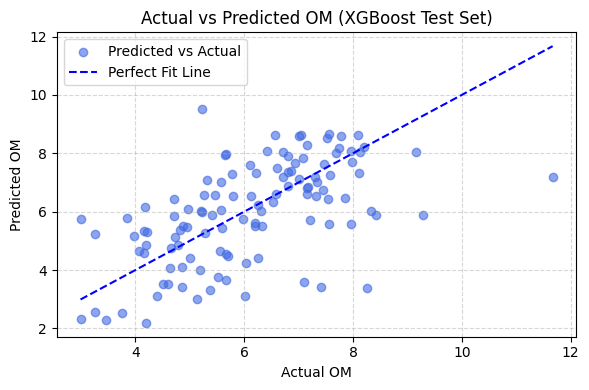

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for XGBoost ===
model = joblib.load("best_xgb_model.pkl")       # ✅ XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati' ,'Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


TEST,XGB,pREDICTED_OM

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")
scaler = joblib.load("scaler_xgb.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Prepare features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Ensure all selected features are present
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Add predictions to original test dataframe ===
df_test_with_pred = df_test.copy()
df_test_with_pred["Predicted_OM"] = y_pred

# === Step 7: Save to CSV ===
df_test_with_pred.to_csv("Antho_Test_1_field_with_predictions.csv", index=False)
print("✅ Predictions saved to Antho_Test_1_field_with_predictions.csv")

# === Step 8: Plot ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")       # XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # Scaler used during training
selected_features = joblib.load("selected_features_xgb.pkl")  # Feature list used in training

# === Step 3: Prepare test data ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns if any and keep the same order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0  # Add missing columns as zeros

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Scale and predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Save results to CSV ===
df_result = pd.DataFrame({
    'Actual_OM': y_test.values,
    'Predicted_OM': y_pred
})
df_result.to_csv("xgb_test_results.csv", index=False)
print("✅ Results saved to xgb_test_results.csv")

# === Step 7: Optional - Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


With_different_trainset_retaining_samefeature_XGBOOST

field_11_train

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_OM_without11.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

# === Step 2: Load selected features from previous model ===
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Prepare training data with selected features ===
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

# Ensure all selected features are present
for col in selected_features:
    if col not in X.columns:
        X[col] = 0

X = X[selected_features].fillna(0)
y = y.loc[X.index]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Step 5: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_scaled, y)
best_xgb = grid_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_scaled), 1):
    X_t, X_v = X_scaled[train_idx], X_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_xgb.fit(X_t, y_t)
    y_pred = best_xgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 7: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Model & Artifacts ===
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler_xgb.pkl")
joblib.dump(selected_features, "selected_features_xgb.pkl")

print("\n✅ Model and scaler saved successfully.")


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/antho_11_test.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")                 # Trained XGBoost model
scaler = joblib.load("scaler_xgb.pkl")                    # StandardScaler used during training
selected_features = joblib.load("selected_features_xgb.pkl")  # List of features used in training

# === Step 3: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Ensure all selected features are present
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0  # Add missing columns as zero

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Scale and predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Save results to Antho_18.csv with latitude & longitude ===
df_result = df_test[['lati', 'long']].copy()
df_result['Actual_OM'] = y_test.values
df_result['Predicted_OM'] = y_pred
df_result.to_csv("Antho_11predict.csv", index=False)
print("✅ File saved as Antho_11predict.csv")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Field_18_test_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")
scaler = joblib.load("scaler_xgb.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Prepare features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Ensure all selected features are present
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Add predictions to original test dataframe ===
df_test_with_pred = df_test.copy()
df_test_with_pred["Predicted_OM"] = y_pred

# === Step 7: Save to CSV ===
df_test_with_pred.to_csv("Antho_Test_1_field_with_predictions.csv", index=False)
print("✅ Predictions saved to Antho_Test_1_field_with_predictions.csv")

# === Step 8: Plot ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_21_testset.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")
scaler = joblib.load("scaler_xgb.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Prepare features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Ensure all selected features are present
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Add predictions to original test dataframe ===
df_test_with_pred = df_test.copy()
df_test_with_pred["Predicted_OM"] = y_pred

# === Step 7: Save to CSV ===
df_test_with_pred.to_csv("Antho_Test_21_field_with_predictions.csv", index=False)
print("✅ Predictions saved to Antho_Test_21_field_with_predictions.csv")

# === Step 8: Plot ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_21_testset.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_xgb_model.pkl")       # XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # Scaler used during training
selected_features = joblib.load("selected_features_xgb.pkl")  # Feature list used in training

# === Step 3: Prepare test data ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns if any and keep the same order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0  # Add missing columns as zeros

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Scale and predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Evaluate ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 6: Save results to CSV ===
df_result = pd.DataFrame({
    'Actual_OM': y_test.values,
    'Predicted_OM': y_pred
})
df_result.to_csv("xgb_test_results.csv", index=False)
print("✅ Results saved to xgb_test_results.csv")

# === Step 7: Optional - Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Ada

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Standarized_Height','long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base AdaBoost ===
base_est = DecisionTreeRegressor(max_depth=3)
ada_base = AdaBoostRegressor(estimator=base_est, n_estimators=100, learning_rate=0.1, random_state=42)
ada_base.fit(X_scaled, y)
perm_importance = permutation_importance(ada_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 10]
}
grid_search = GridSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ada = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_ada.fit(X_t, y_t)
    y_pred = best_ada.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_ada, "best_ada_model.pkl")
joblib.dump(scaler, "scaler_ada.pkl")
joblib.dump(selected_features, "selected_features_ada.pkl")


📌 Selected Features (12 of 31):
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Clay_polaris
 - Ksat_Polaris
 - PH_Polaris
 - Theta_r_Polaris
 - SILT_Polaris
 - Lamda_Polaris
 - SAND_Polaris
 - pctearthmc
 - ncci3all

✅ Best Hyperparameters:
{'estimator__max_depth': 10, 'learning_rate': 0.1, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.4122, MAE: 1.0670, RMSE: 1.6024, R²: 0.6200
Fold 2 → MBE: -0.3378, MAE: 1.3121, RMSE: 1.8118, R²: 0.3714
Fold 3 → MBE: 0.3788, MAE: 0.7890, RMSE: 0.9680, R²: 0.7289
Fold 4 → MBE: -0.0022, MAE: 1.0520, RMSE: 1.5203, R²: 0.5370
Fold 5 → MBE: -0.3606, MAE: 1.1836, RMSE: 1.7453, R²: 0.5246
Fold 6 → MBE: 0.1381, MAE: 0.9569, RMSE: 1.3935, R²: 0.6166
Fold 7 → MBE: -0.0930, MAE: 0.9914, RMSE: 1.4169, R²: 0.5712
Fold 8 → MBE: -0.2000, MAE: 1.0308, RMSE: 1.4809, R²: 0.6471
Fold 9 → MBE: -0.1301, MAE: 0.9646, RMSE: 1.3850, R²: 0.6500
Fold 10 → MBE: -0.3115, MAE: 1.0991, RMSE: 1.7118, R²: 0.5876

📌 Average 10-Fold Metrics:
MBE:  -0.1331
MAE:  1.0447
RMSE: 1.50

['selected_features_ada.pkl']

ADA_TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Clay_polaris
 - Ksat_Polaris
 - PH_Polaris
 - Theta_r_Polaris
 - SILT_Polaris
 - Lamda_Polaris
 - SAND_Polaris
 - pctearthmc
 - ncci3all

📊 Test Set Metrics (AdaBoost):
MBE:  -0.4710
MAE:  0.9015
RMSE: 1.2414
R²:   0.3192


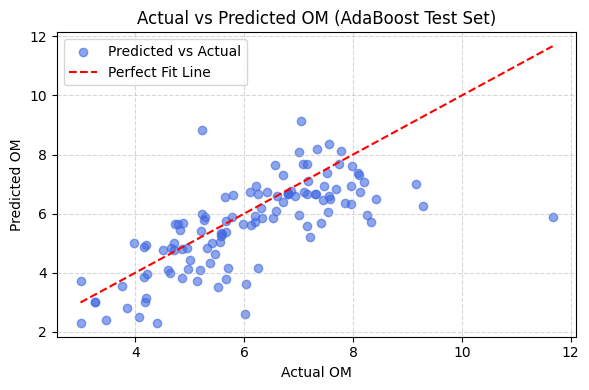

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for AdaBoost ===
model = joblib.load("best_ada_model.pkl")        # ✅ AdaBoost model
scaler = joblib.load("scaler_ada.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_ada.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print metrics
print("\n📊 Test Set Metrics (AdaBoost):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (AdaBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


CAT_regression_train

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.8 MB/s eta 0:00:00



📊 Per Fold Metrics:
Fold 1: MBE=-0.1667, MAE=1.0991, RMSE=1.5102, R²=0.6625
Fold 2: MBE=-0.1151, MAE=1.1769, RMSE=1.5493, R²=0.5403
Fold 3: MBE=0.4865, MAE=0.8100, RMSE=1.0453, R²=0.6839
Fold 4: MBE=0.0818, MAE=1.1124, RMSE=1.5050, R²=0.5463
Fold 5: MBE=-0.1697, MAE=1.1823, RMSE=1.6206, R²=0.5901
Fold 6: MBE=0.1926, MAE=0.8790, RMSE=1.1614, R²=0.7337
Fold 7: MBE=0.0251, MAE=1.0472, RMSE=1.3337, R²=0.6201
Fold 8: MBE=-0.0035, MAE=0.9053, RMSE=1.2970, R²=0.7293
Fold 9: MBE=-0.0696, MAE=0.9145, RMSE=1.2873, R²=0.6976
Fold 10: MBE=-0.2086, MAE=1.0969, RMSE=1.6581, R²=0.6131

📌 Average 10-Fold Metrics:
MBE:  0.0053
MAE:  1.0224
RMSE: 1.3968
R²:   0.6417


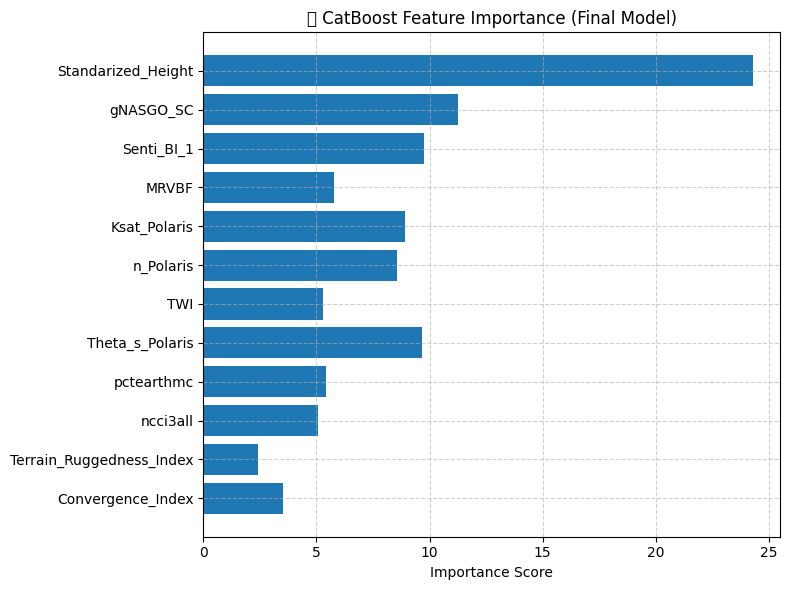

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
cat_base = CatBoostRegressor(verbose=0, random_state=42)
cat_base.fit(X_scaled, y)
perm_importance = permutation_importance(cat_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scaling Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_cat = grid_search.best_estimator_

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_cat.fit(X_t, y_t)
    y_pred = best_cat.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_cat, "best_cat_model.pkl")
joblib.dump(scaler, "scaler_cat.pkl")
joblib.dump(selected_features, "selected_features_cat.pkl")

# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_feat_importance)
plt.title("📌 CatBoost Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Use averaged metrics directly from the folds ===
mbe_cv = np.mean(metrics['mbe'])
mae_cv = np.mean(metrics['mae'])
rmse_cv = np.mean(metrics['rmse'])
r2_cv = np.mean(metrics['r2'])

# === Plot Actual vs Predicted (using y_all_actual and y_all_predicted) ===
plt.figure(figsize=(5, 4))
plt.scatter(y_all_actual, y_all_predicted, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([min(y_all_actual), max(y_all_actual)], [min(y_all_actual), max(y_all_actual)], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Catboost 10-Fold CV)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# === Add metrics box inside the plot ===
metrics_text = (
    f"MBE:  {mbe_cv:.2f}\n"
    f"MAE:  {mae_cv:.2f}\n"
    f"RMSE: {rmse_cv:.2f}\n"
    f"R²:   {r2_cv:.2f}"
)
plt.text(
    0.05, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8)
)

plt.tight_layout()
plt.savefig("actual_vs_predicted_cv_with_fold_avg_metrics.png", dpi=300)
plt.show()


NameError: name 'y_all_actual' is not defined

<Figure size 500x400 with 0 Axes>

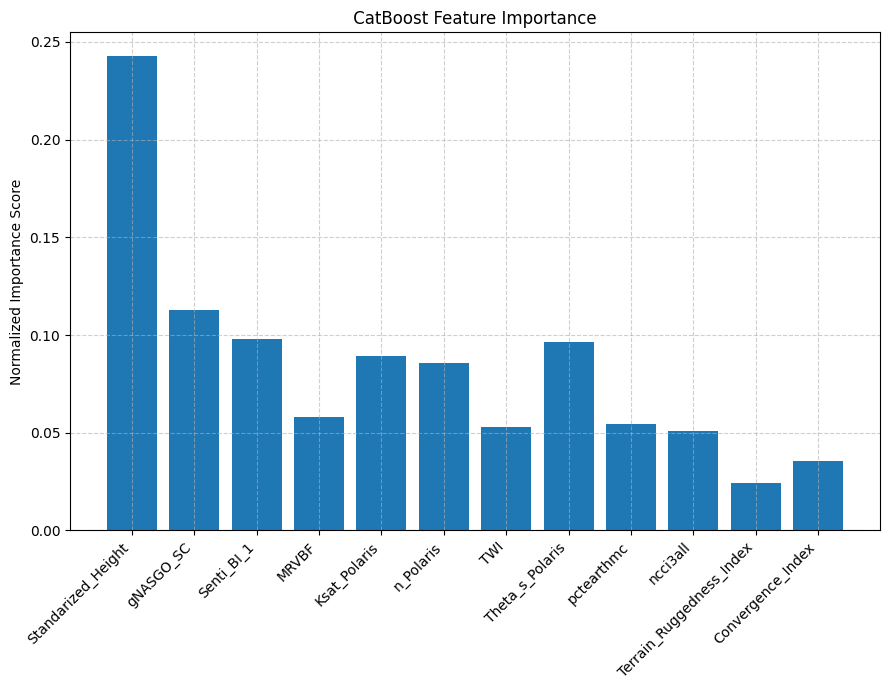

In [ ]:
# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))

# Normalize to sum to 1
final_feat_importance_normalized = final_feat_importance / np.sum(final_feat_importance)

plt.figure(figsize=(9, 7))
plt.bar(selected_features, final_feat_importance_normalized)
plt.title(" CatBoost Feature Importance ")
plt.ylabel("Normalized Importance Score")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


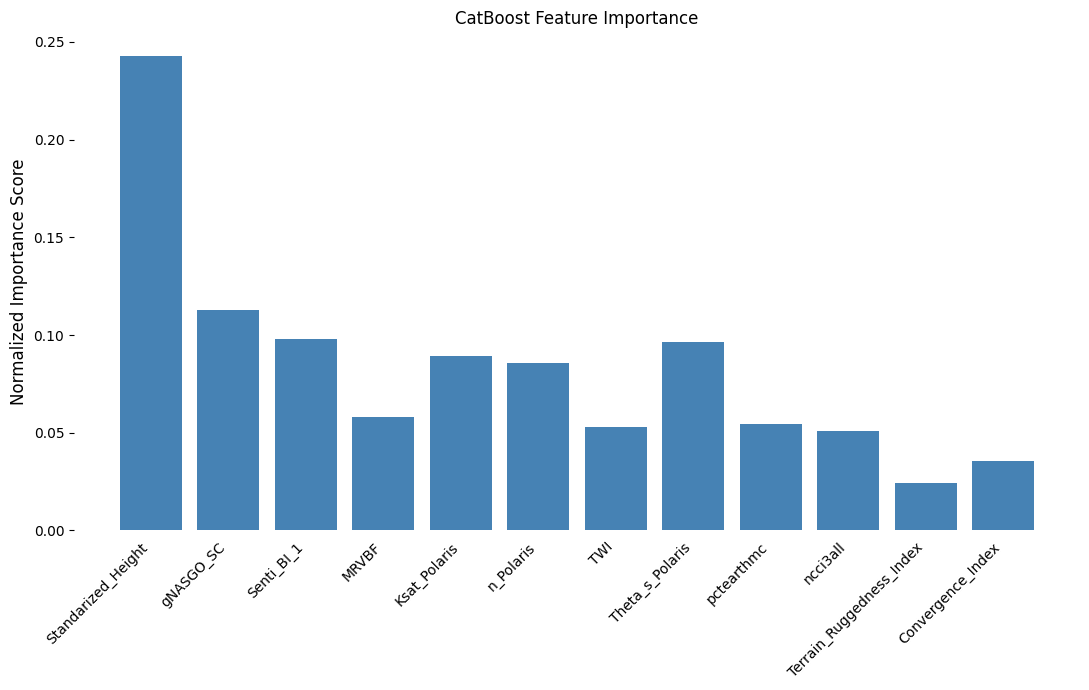

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from catboost import Pool

# Assuming you already have:
# - selected_features (list of feature names)
# - X_selected_scaled (scaled feature matrix)
# - y (target variable)
# - best_cat (fitted CatBoost model)

# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))
final_feat_importance_normalized = final_feat_importance / np.sum(final_feat_importance)

plt.figure(figsize=(11, 7))
bars = plt.bar(selected_features, final_feat_importance_normalized, color='steelblue')

# Aesthetic settings for "plain" look
plt.title("CatBoost Feature Importance", fontsize=12,)
plt.ylabel("Normalized Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', right=False)

# Remove background grid and frame
plt.grid(False)
plt.gca().set_facecolor('white')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()


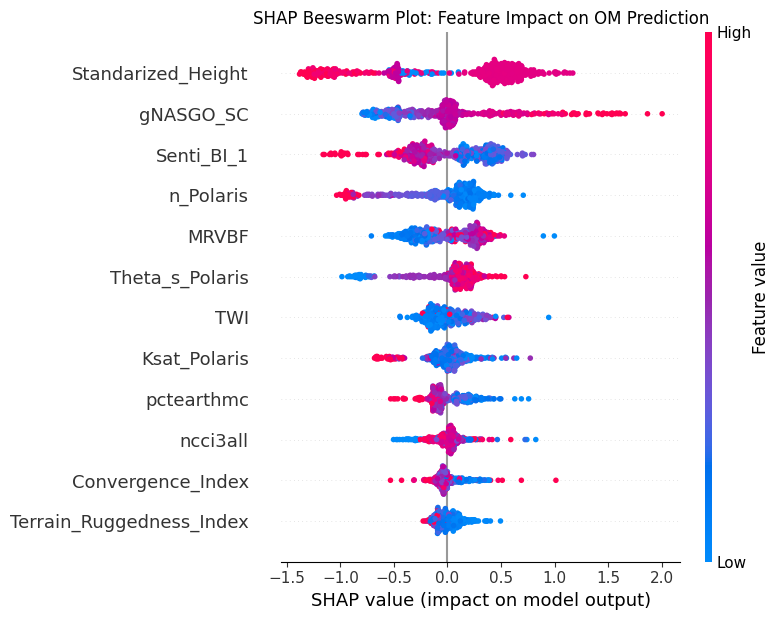

In [ ]:
import shap

# === Step 10: SHAP Beeswarm Plot for Selected Features ===

# Load model and selected features
model = joblib.load("/content/best_cat_model.pkl")
selected_features = joblib.load("/content/selected_features_cat.pkl")

# Prepare original unscaled selected features DataFrame
X_selected_df = X[selected_features]

# Fit the model again on full data (unscaled) to match SHAP expectations
model.fit(X_selected_df, y)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# Plot SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm_selected_features.png", dpi=300, bbox_inches='tight')
plt.show()


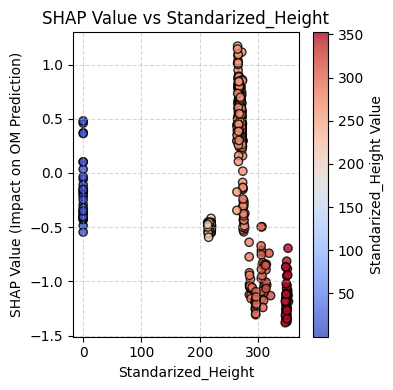

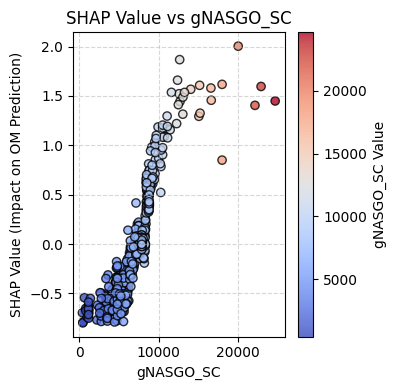

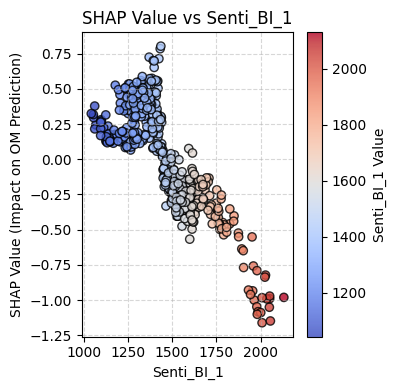

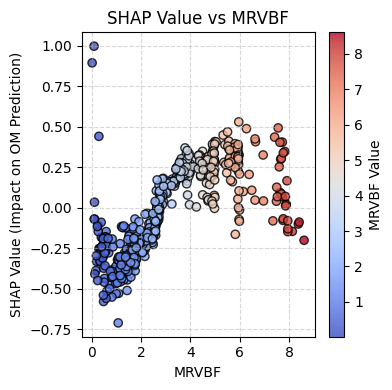

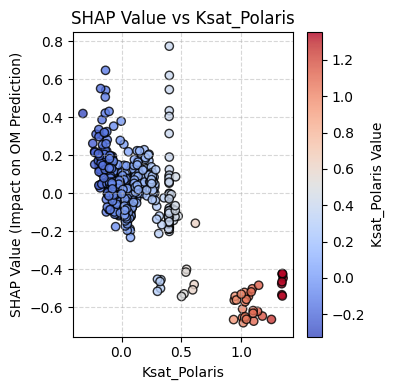

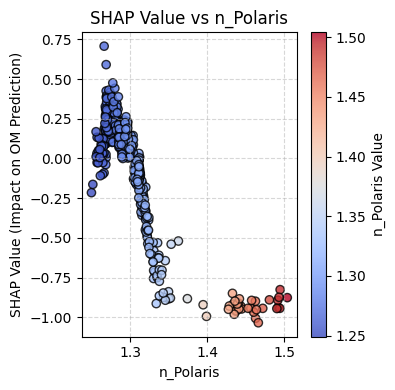

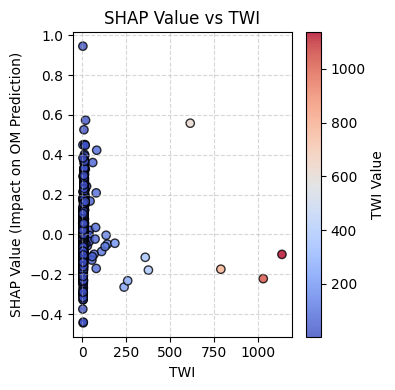

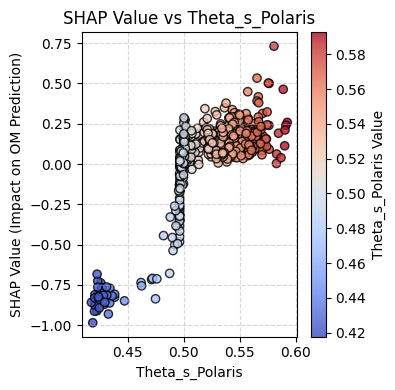

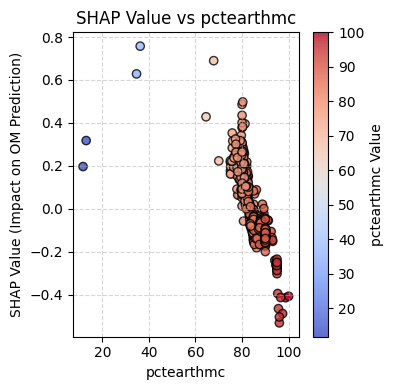

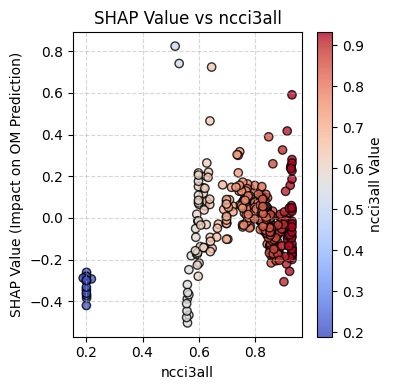

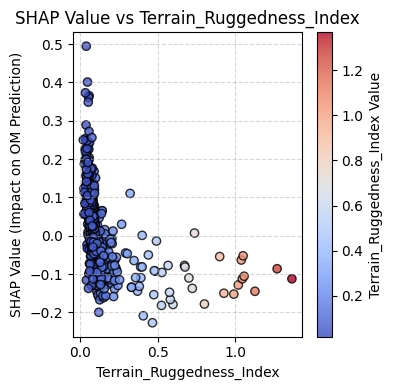

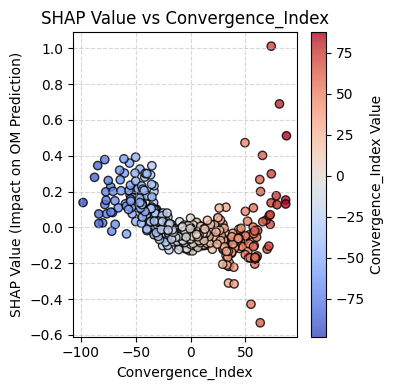

In [ ]:
import shap
import matplotlib.pyplot as plt
import joblib

# === Load artifacts ===
model = joblib.load("/content/best_cat_model.pkl")
selected_features = joblib.load("/content/selected_features_cat.pkl")

# Prepare input
X_selected_df = X[selected_features]  # original feature values (not scaled)
model.fit(X_selected_df, y)

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# === Loop through features ===
for feature in selected_features:
    feature_index = selected_features.index(feature)
    feature_values = X_selected_df[feature].values
    shap_vals = shap_values[:, feature_index].values

    plt.figure(figsize=(4, 4), dpi=100)
    scatter = plt.scatter(
        feature_values,
        shap_vals,
        c=feature_values,
        cmap='coolwarm',
        edgecolors='k',
        alpha=0.8
    )
    plt.colorbar(scatter, label=f"{feature} Value")
    plt.xlabel(f"{feature}")
    plt.ylabel("SHAP Value (Impact on OM Prediction)")
    plt.title(f"SHAP Value vs {feature}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{feature}.png", dpi=300, bbox_inches='tight')
    plt.show()


CAT_TEST

🔍 Features used for prediction:
 - Standarized_Height
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Ksat_Polaris
 - n_Polaris
 - TWI
 - Theta_s_Polaris
 - pctearthmc
 - ncci3all
 - Terrain_Ruggedness_Index
 - Convergence_Index

📊 Test Set Metrics (CatBoost):
MBE:  0.063
MAE:  0.792
RMSE: 1.047
R²:   0.52


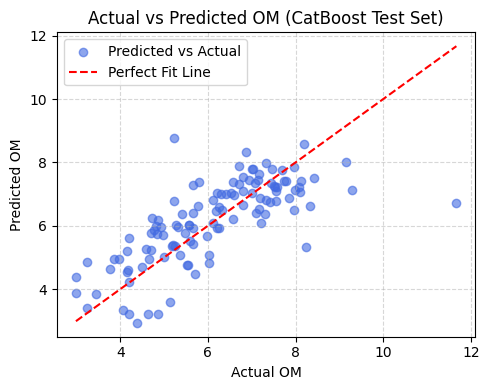

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for CatBoost ===
model = joblib.load("best_cat_model.pkl")        # ✅ CatBoost model
scaler = joblib.load("scaler_cat.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_cat.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (CatBoost):")
print(f"MBE:  {mbe:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.2f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


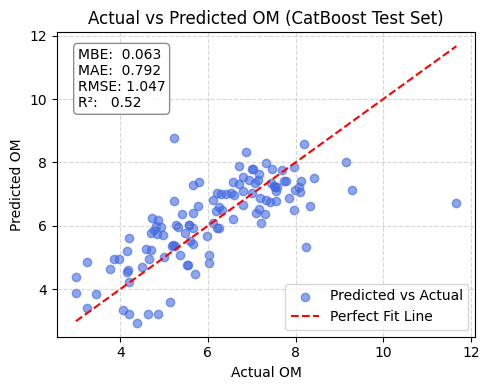

In [ ]:
# === Step 8: Plot Actual vs Predicted with Metrics Box ===
plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")

plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add metrics inside a box
metrics_text = (
    f"MBE:  {mbe:.3f}\n"
    f"MAE:  {mae:.3f}\n"
    f"RMSE: {rmse:.3f}\n"
    f"R²:   {r2:.2f}"
)

plt.text(
    0.05, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
)

plt.tight_layout()
plt.show()


Train_LightGBM

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


📊 Per Fold Metrics:
Fold 1: MBE=-0.2052, MAE=0.9750, RMSE=1.4270, R²=0.6986
Fold 2: MBE=-0.0487, MAE=1.1434, RMSE=1.4918, R²=0.5738


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Fold 3: MBE=0.4104, MAE=0.7171, RMSE=0.9503, R²=0.7387
Fold 4: MBE=0.1235, MAE=1.2344, RMSE=1.6144, R²=0.4779
Fold 5: MBE=-0.0376, MAE=1.1536, RMSE=1.5814, R²=0.6097


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Fold 6: MBE=0.1426, MAE=0.9436, RMSE=1.2936, R²=0.6696
Fold 7: MBE=-0.0234, MAE=1.0998, RMSE=1.3551, R²=0.6078
Fold 8: MBE=-0.0517, MAE=0.8870, RMSE=1.3113, R²=0.7233


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 9: MBE=-0.0581, MAE=0.9263, RMSE=1.3210, R²=0.6816
Fold 10: MBE=-0.3063, MAE=1.0655, RMSE=1.5815, R²=0.6480

📌 Average 10-Fold Metrics:
MBE:  -0.0055
MAE:  1.0146
RMSE: 1.3927
R²:   0.6429


/tmp/ipython-input-12-1080333387.py:98: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


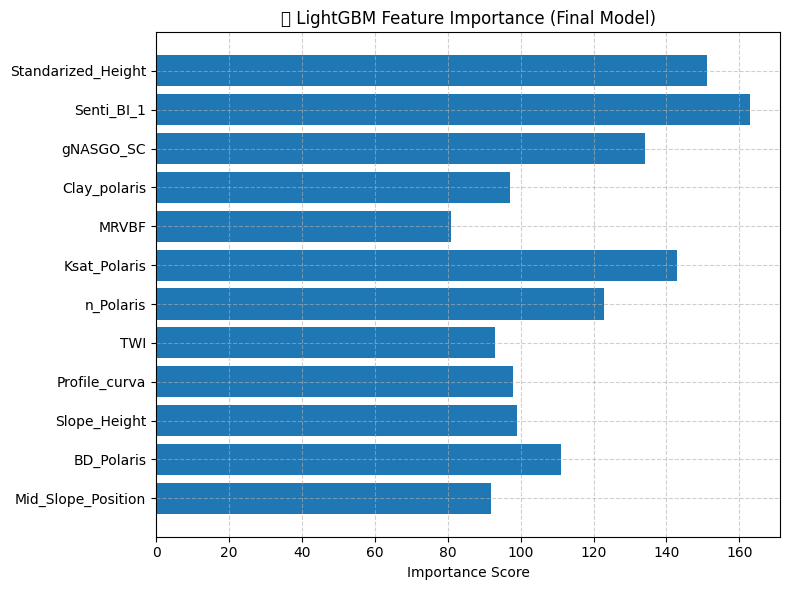

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev' ,'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
lgb_base = LGBMRegressor(random_state=42, verbose=-1)
lgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(lgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63],
    'reg_alpha': [0, 0.1, 1.0]
}

grid_search = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_lgb = grid_search.best_estimator_

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_lgb.fit(X_t, y_t)
    y_pred = best_lgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

# === Step 9: Plot Feature Importances ===
feat_importance = best_lgb.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, feat_importance)
plt.title("📌 LightGBM Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

TEST_LIGHTGBM

🔍 Features used for prediction:
 - Standarized_Height
 - Senti_BI_1
 - gNASGO_SC
 - Clay_polaris
 - MRVBF
 - Ksat_Polaris
 - n_Polaris
 - TWI
 - Profile_curva
 - Slope_Height
 - BD_Polaris
 - Mid_Slope_Position

📊 Test Set Metrics (LightGBM):
MBE:  -0.3606
MAE:  1.0609
RMSE: 1.4064
R²:   0.1261


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


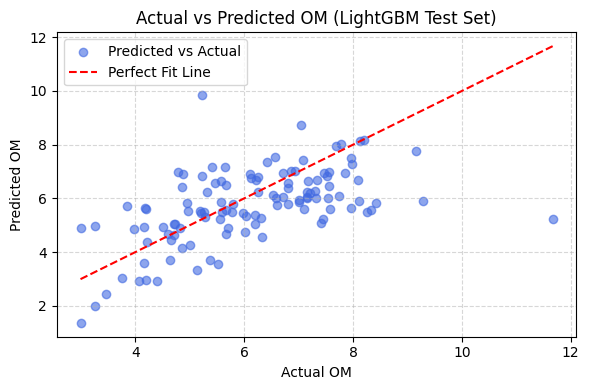

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("best_lgb_model.pkl")        # ✅ LightGBM model
scaler = joblib.load("scaler_lgb.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_lgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train_Bayasian_Ridge


📊 Per Fold Metrics:
Fold 1: MBE=-0.2568, MAE=1.3370, RMSE=1.8954, R²=0.4683
Fold 2: MBE=-0.4100, MAE=1.4333, RMSE=1.8775, R²=0.3249
Fold 3: MBE=0.6848, MAE=0.9939, RMSE=1.2384, R²=0.5562
Fold 4: MBE=-0.2239, MAE=1.2422, RMSE=1.7024, R²=0.4195
Fold 5: MBE=-0.2245, MAE=1.5489, RMSE=1.9422, R²=0.4112
Fold 6: MBE=0.6627, MAE=1.3702, RMSE=1.7287, R²=0.4099
Fold 7: MBE=0.1332, MAE=1.3346, RMSE=1.6232, R²=0.4372
Fold 8: MBE=-0.0962, MAE=1.3006, RMSE=1.6965, R²=0.5369
Fold 9: MBE=-0.0337, MAE=1.2929, RMSE=1.7517, R²=0.4401
Fold 10: MBE=-0.2242, MAE=1.4800, RMSE=1.9169, R²=0.4829

📌 Average 10-Fold Metrics:
MBE:  0.0011
MAE:  1.3334
RMSE: 1.7373
R²:   0.4487


/tmp/ipython-input-14-645871609.py:89: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


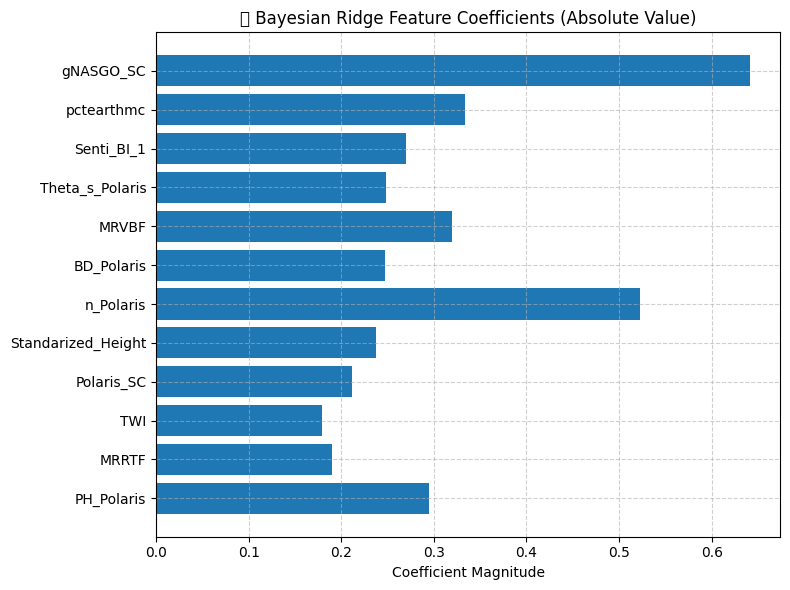

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
ridge_base = BayesianRidge()
ridge_base.fit(X_scaled, y)
perm_importance = permutation_importance(ridge_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Use Best Bayesian Ridge Model (no hyperparameters to tune here) ===
best_ridge = BayesianRidge()
best_ridge.fit(X_selected_scaled, y)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_ridge.fit(X_t, y_t)
    y_pred = best_ridge.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_ridge, "best_bayes_model.pkl")
joblib.dump(scaler, "scaler_bayes.pkl")
joblib.dump(selected_features, "selected_features_bayes.pkl")

# === Step 9: Plot Coefficients ===
coef_importance = best_ridge.coef_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, np.abs(coef_importance))
plt.title("📌 Bayesian Ridge Feature Coefficients (Absolute Value)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - pctearthmc
 - Senti_BI_1
 - Theta_s_Polaris
 - MRVBF
 - BD_Polaris
 - n_Polaris
 - Standarized_Height
 - Polaris_SC
 - TWI
 - MRRTF
 - PH_Polaris

📊 Test Set Metrics (LightGBM):
MBE:  -0.3907
MAE:  0.8810
RMSE: 1.1255
R²:   0.4403


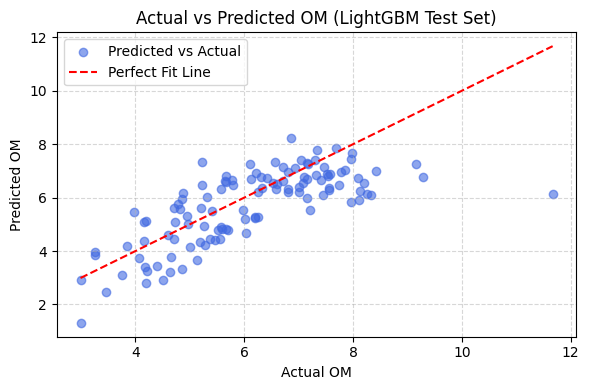

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("/content/best_bayes_model.pkl")        # ✅ LightGBM model
scaler = joblib.load("/content/scaler_bayes.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("/content/selected_features_bayes.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


MLP_Train


📊 Per Fold Metrics:
Fold 1: MBE=-0.0801, MAE=1.2809, RMSE=1.8953, R²=0.4684
Fold 2: MBE=-0.1157, MAE=1.5566, RMSE=2.1584, R²=0.1079
Fold 3: MBE=0.5146, MAE=0.9188, RMSE=1.2126, R²=0.5745
Fold 4: MBE=0.3087, MAE=1.5191, RMSE=1.8820, R²=0.2905


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5: MBE=0.0769, MAE=1.3300, RMSE=1.8715, R²=0.4533


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 6: MBE=0.2056, MAE=1.2049, RMSE=1.7382, R²=0.4034


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 9: MBE=-0.1461, MAE=1.0611, RMSE=1.4139, R²=0.6352


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 10: MBE=-0.2425, MAE=1.4164, RMSE=2.0503, R²=0.4084

📌 Average 10-Fold Metrics:
MBE:  0.1054
MAE:  1.2625
RMSE: 1.7402
R²:   0.4393


/tmp/ipython-input-16-4081087770.py:91: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


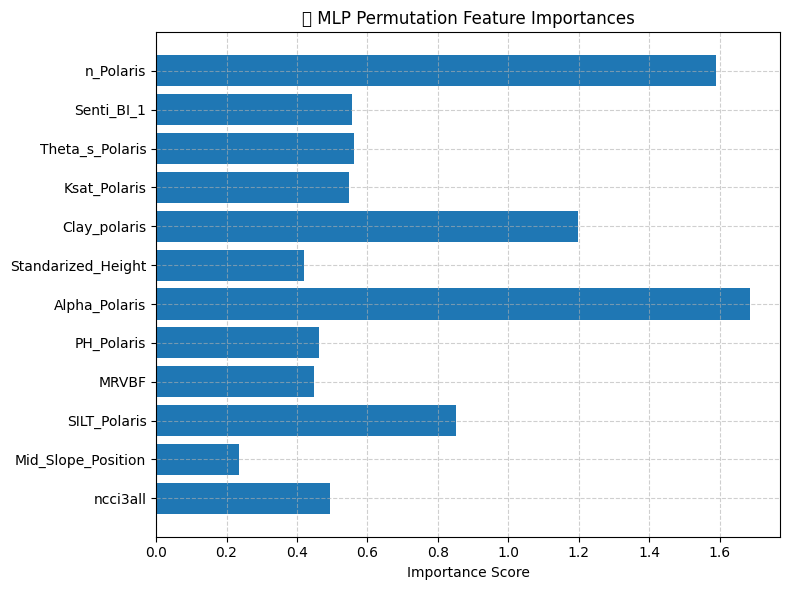

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base MLP ===
mlp_base = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_base.fit(X_scaled, y)
perm_importance = permutation_importance(mlp_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final MLP Regressor ===
best_mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                        solver='adam', learning_rate_init=0.001,
                        max_iter=1000, random_state=42)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_mlp.fit(X_t, y_t)
    y_pred = best_mlp.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_mlp, "best_mlp_model.pkl")
joblib.dump(scaler, "scaler_mlp.pkl")
joblib.dump(selected_features, "selected_features_mlp.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
mlp_final_importance = permutation_importance(best_mlp, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = mlp_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 MLP Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Modi_Stacking

TEST

WITH cat meta learner

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using CatBoost Importance ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

cb_selector = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cb_selector.fit(X_scaled_full, y)

importances = cb_selector.get_feature_importance()
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42))
]

meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# === Step 5: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 6: Summary ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save Artifacts ===
joblib.dump(stack, "stacked_model_rf_ada_cat.pkl")
joblib.dump(scaler, "scaler_rf_ada_cat.pkl")
joblib.dump(selected_features, "features_rf_ada_cat.pkl")



📊 Per Fold Metrics:
Fold 1: MBE=-0.2179, MAE=1.0925, RMSE=1.5355, R²=0.6511
Fold 2: MBE=-0.1093, MAE=1.1694, RMSE=1.5109, R²=0.5628
Fold 3: MBE=0.5291, MAE=0.8423, RMSE=1.0617, R²=0.6739
Fold 4: MBE=0.1376, MAE=1.0788, RMSE=1.4373, R²=0.5862
Fold 5: MBE=-0.1259, MAE=1.2287, RMSE=1.6179, R²=0.5914
Fold 6: MBE=0.2089, MAE=0.9590, RMSE=1.2820, R²=0.6755
Fold 7: MBE=-0.0390, MAE=1.1114, RMSE=1.3863, R²=0.5896
Fold 8: MBE=-0.0345, MAE=0.9068, RMSE=1.2995, R²=0.7283
Fold 9: MBE=-0.0724, MAE=0.9929, RMSE=1.3739, R²=0.6556
Fold 10: MBE=-0.1805, MAE=1.1177, RMSE=1.6507, R²=0.6165

📌 Average 10-Fold Metrics:
MBE:  0.0096
MAE:  1.0500
RMSE: 1.4156
R²:   0.6331


['features_rf_ada_cat.pkl']

In [ ]:
print("\n📌 Selected Features Used in the Model:")
print(selected_features)



📌 Selected Features Used in the Model:
['Standarized_Height', 'gNASGO_SC', 'Senti_BI_1', 'MRVBF', 'Ksat_Polaris', 'n_Polaris', 'TWI', 'Theta_s_Polaris', 'pctearthmc', 'ncci3all', 'Terrain_Ruggedness_Index', 'Convergence_Index']


Average in Skakingfeature slection ada, rf

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.1 MB/s eta 0:00:00


AveRAGE ALL , CAT EXCLUDE STACKING

In [18]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor # Import StackingRegressor
)
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using Averaged Importance from Base Models (no HGB) ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Fit all base models
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
et = ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42)
lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
bayridge = BayesianRidge()
knn = KNeighborsRegressor(n_neighbors=4)

models = [rf, ada, gbr, et, xgb, lgbm, bayridge]  # ⛔ Removed hgb

# Store importances
importances = []

for model in models:
    model.fit(X_scaled_full, y)
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        importances.append(np.abs(model.coef_) / np.sum(np.abs(model.coef_)))  # Normalized for comparison

# Average importances
avg_importance = np.mean(importances, axis=0)

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Avg_Importance': avg_importance
}).sort_values(by='Avg_Importance', ascending=False)




# Select top 10 features
top_k = 10
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('rf', rf),
    ('ada', ada),
    ('gbr', gbr),
    ('et', et),
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('knn', knn),
    ('bayridge', bayridge)
]

meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# === Step 5: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 6: Summary ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.3f}")
print(f"MAE:  {np.mean(metrics['mae']):.3f}")
print(f"RMSE: {np.mean(metrics['rmse']):.3f}")
print(f"R²:   {np.mean(metrics['r2']):.2f}")




# === Step 7: Save Artifacts ===
joblib.dump(stack, "stacked_model_ensemble_noHGB_catmeta.pkl")
joblib.dump(scaler, "scaler_selected_features.pkl")
joblib.dump(selected_features, "features_selected_from_ensemble.pkl")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 31
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

['features_selected_from_ensemble.pkl']

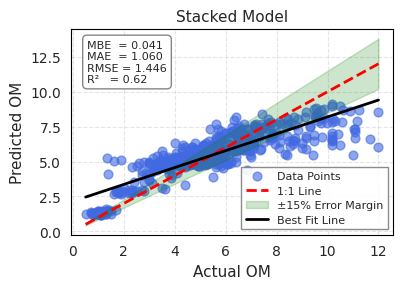

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === Use exact precomputed average CV metrics ===
mbe_cv = 0.041
mae_cv = 1.060
rmse_cv = 1.446
r2_cv = 0.62

# === Use final stacked model to get predictions ===
y_pred_full = stack.predict(X_scaled_selected)

# === Create DataFrame for plotting ===
plot_df = pd.DataFrame({
    'Actual_OM': y,
    'Predicted_OM': y_pred_full
})

# === Regression fit for best-fit line ===
reg = LinearRegression()
reg.fit(plot_df[['Actual_OM']], plot_df['Predicted_OM'])
y_fit = reg.predict(plot_df[['Actual_OM']])
r2 = r2_score(plot_df['Predicted_OM'], y_fit)

# === Sort values for proper fill_between ===
sorted_df = plot_df.sort_values(by='Actual_OM')
x_sorted = sorted_df['Actual_OM'].values
y_sorted = sorted_df['Predicted_OM'].values
y_fit_sorted = reg.predict(x_sorted.reshape(-1, 1))

# ±15% bounds
upper = x_sorted * 1.15
lower = x_sorted * 0.85

# === Plot ===
plt.figure(figsize=(4, 3))  # Reportable size
ax = plt.gca()
ax.grid(True, linestyle='--', alpha=0.5)

# Add thin black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# Scatter plot
plt.scatter(x_sorted, y_sorted, color='royalblue', alpha=0.6, s=40, label='Data Points')

# 1:1 line
plt.plot([x_sorted.min(), x_sorted.max()], [x_sorted.min(), x_sorted.max()],
         color='red', linestyle='--', linewidth=2, label='1:1 Line')

# ±15% Error margin
plt.fill_between(x_sorted, lower, upper, color='green', alpha=0.2, label='±15% Error Margin')

# Best-fit regression line
plt.plot(x_sorted, y_fit_sorted, color='black', linewidth=2, label='Best Fit Line')

# 📦 Metrics box (with smaller font)
metrics_text = (
    f"MBE  = {mbe_cv:.3f}\n"
    f"MAE  = {mae_cv:.3f}\n"
    f"RMSE = {rmse_cv:.3f}\n"
    f"R²   = {r2_cv:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,  # reduced font size inside box
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.95)
)

# Labels and Title
plt.xlabel("Actual OM", fontsize=11)
plt.ylabel("Predicted OM", fontsize=11)
plt.title("Stacked Model", fontsize=11)

# 🧾 Compact legend box
plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=0.9,
    edgecolor='gray',
    labelspacing=0.4
)

plt.tight_layout()
plt.show()


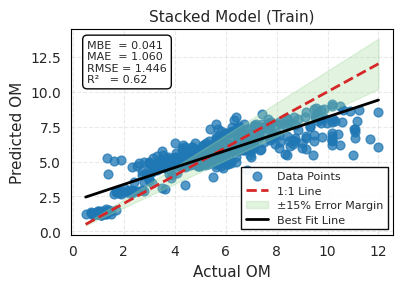

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === Use exact precomputed average CV metrics ===
mbe_cv = 0.041
mae_cv = 1.060
rmse_cv = 1.446
r2_cv = 0.62

# === Use final stacked model to get predictions ===
y_pred_full = stack.predict(X_scaled_selected)

# === Create DataFrame for plotting ===
plot_df = pd.DataFrame({
    'Actual_OM': y,
    'Predicted_OM': y_pred_full
})

# === Regression fit for best-fit line ===
reg = LinearRegression()
reg.fit(plot_df[['Actual_OM']], plot_df['Predicted_OM'])
y_fit = reg.predict(plot_df[['Actual_OM']])
r2 = r2_score(plot_df['Predicted_OM'], y_fit)

# === Sort values for proper fill_between ===
sorted_df = plot_df.sort_values(by='Actual_OM')
x_sorted = sorted_df['Actual_OM'].values
y_sorted = sorted_df['Predicted_OM'].values
y_fit_sorted = reg.predict(x_sorted.reshape(-1, 1))

# ±15% bounds
upper = x_sorted * 1.15
lower = x_sorted * 0.85

# === Plot ===
plt.figure(figsize=(4, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')  # Ensure plot background is white
ax.grid(True, linestyle='--', alpha=0.4)

# Add thin black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# Scatter plot - brighter blue
plt.scatter(x_sorted, y_sorted, color='#1f77b4', alpha=0.75, s=40, label='Data Points')

# 1:1 line - deeper red
plt.plot([x_sorted.min(), x_sorted.max()], [x_sorted.min(), x_sorted.max()],
         color='#d62728', linestyle='--', linewidth=2, label='1:1 Line')

# ±15% Error margin - light green
plt.fill_between(x_sorted, lower, upper, color='#a1d99b', alpha=0.3, label='±15% Error Margin')

# Best-fit regression line - strong black
plt.plot(x_sorted, y_fit_sorted, color='black', linewidth=2, label='Best Fit Line')

# 📦 Metrics box
metrics_text = (
    f"MBE  = {mbe_cv:.3f}\n"
    f"MAE  = {mae_cv:.3f}\n"
    f"RMSE = {rmse_cv:.3f}\n"
    f"R²   = {r2_cv:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor='black', facecolor='white', alpha=0.97)
)

# Labels and Title
plt.xlabel("Actual OM", fontsize=11)
plt.ylabel("Predicted OM", fontsize=11)
plt.title("Stacked Model (Train)", fontsize=11)

# 🧾 Brighter, compact legend
plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor='black',
    facecolor='white',
    labelspacing=0.4
)

plt.tight_layout()
plt.show()


In [ ]:
pip install shap


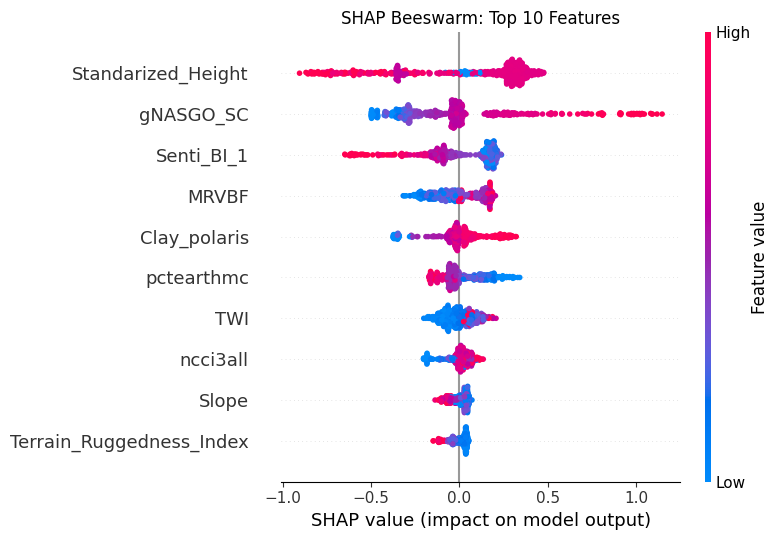


✅ SHAP beeswarm plot generated for original top 10 features (meta-learner perspective only).


In [ ]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# === Load model and supporting artifacts ===
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")
scaler = joblib.load("/content/scaler_selected_features.pkl")

# === Load and prepare data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

X_selected_df = X[selected_features]
X_scaled_selected = scaler.transform(X_selected_df)

# === Get base model predictions ===
fitted_base_models = model.estimators_
base_model_names = [name for name, _ in model.estimators]

base_model_predictions = []
for name, base_model in zip(base_model_names, fitted_base_models):
    preds = base_model.predict(X_scaled_selected)
    base_model_predictions.append(preds)

stacked_preds = np.vstack(base_model_predictions).T
meta_input = np.hstack([stacked_preds, X_scaled_selected])  # order: predictions + passthrough features

# === Create SHAP explainer for meta-learner ===
meta_learner = model.final_estimator_
background_data = shap.utils.sample(meta_input, 100)

explainer = shap.Explainer(meta_learner, background_data)
shap_values = explainer(meta_input)

# === Feature names: base model preds + original features ===
meta_feature_names = [f"{name}_pred" for name in base_model_names] + selected_features
shap_values.feature_names = meta_feature_names

# === Step: Extract only SHAP values for original features ===
# These are in the second half of the meta_input
n_base = len(base_model_names)
shap_vals_only_passthrough = shap_values[:, n_base:]  # Only the last 10 columns (passthrough features)

# === Beeswarm plot for passthrough features only ===
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_vals_only_passthrough, max_display=10, show=False)
plt.title("SHAP Beeswarm: Top 10 Features", fontsize=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_meta_passthrough_only.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ SHAP beeswarm plot generated for original top 10 features (meta-learner perspective only).")


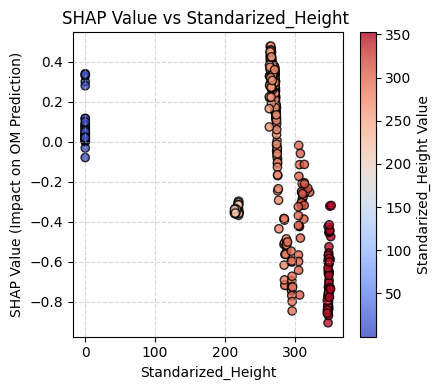

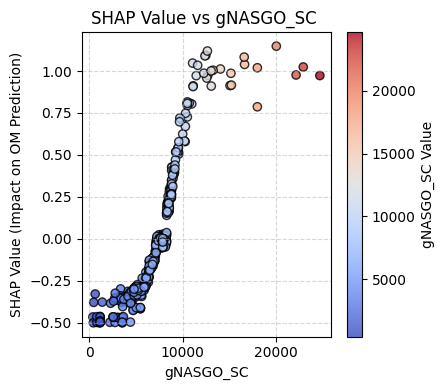

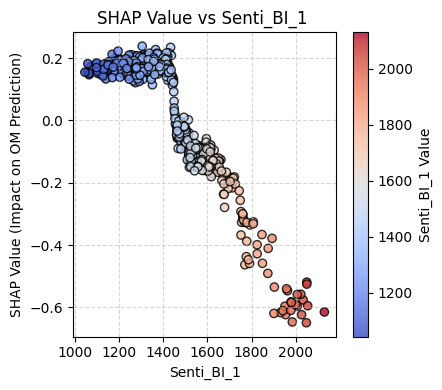

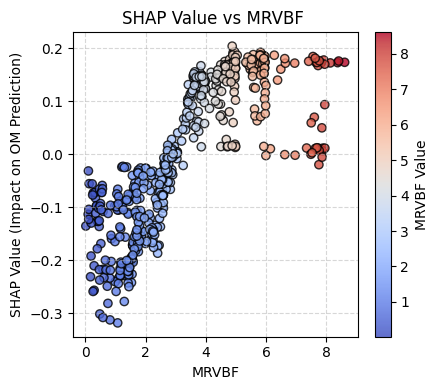

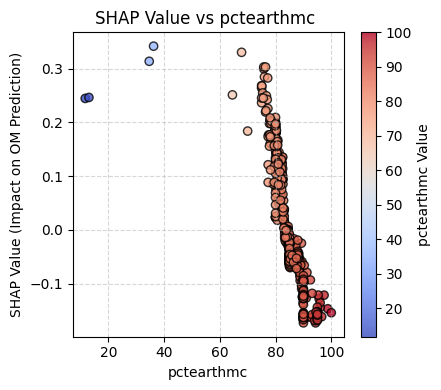

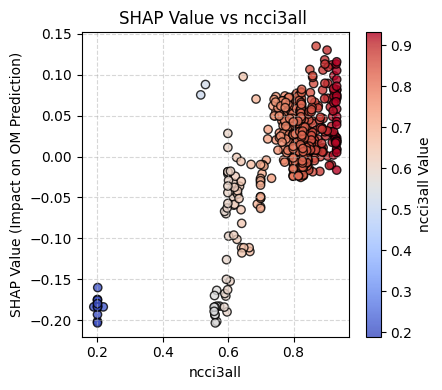

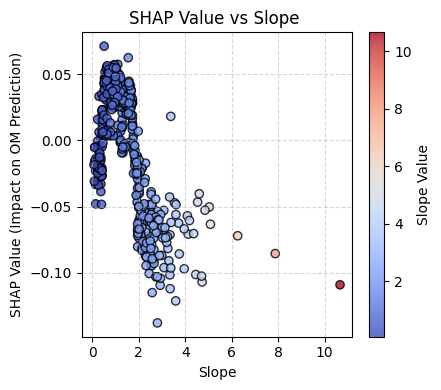

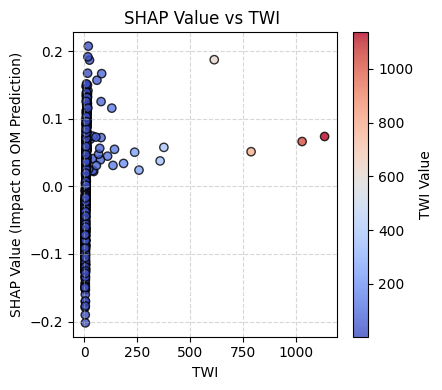

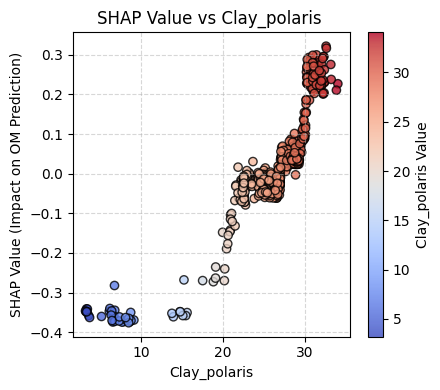

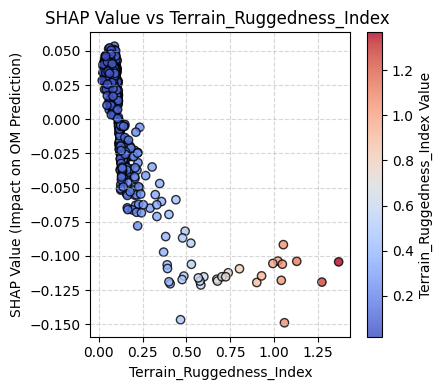

In [ ]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# === Load model and artifacts ===
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")
scaler = joblib.load("/content/scaler_selected_features.pkl")

# === Load and prepare data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Prepare input for meta-learner (stacked predictions + passthrough features) ===
X_selected_df = X[selected_features]
X_scaled_selected = scaler.transform(X_selected_df)

# Base model predictions
fitted_base_models = model.estimators_
base_model_names = [name for name, _ in model.estimators]
base_model_predictions = [bm.predict(X_scaled_selected) for bm in fitted_base_models]

stacked_preds = np.vstack(base_model_predictions).T
meta_input = np.hstack([stacked_preds, X_scaled_selected])

# === SHAP Explainer on meta-learner ===
meta_learner = model.final_estimator_
background_data = shap.utils.sample(meta_input, 100)
explainer = shap.Explainer(meta_learner, background_data)
shap_values = explainer(meta_input)

# === Get SHAP values for passthrough (original) features only ===
n_base = len(base_model_names)
shap_vals_passthrough = shap_values[:, n_base:]
X_selected_df_scaled = pd.DataFrame(X_scaled_selected, columns=selected_features)

# === Loop through each passthrough feature and create individual plots ===
for i, feature in enumerate(selected_features):
    shap_vals = shap_vals_passthrough.values[:, i]
    feature_vals = X_selected_df[feature].values  # unscaled for interpretability

    plt.figure(figsize=(4.5, 4))
    scatter = plt.scatter(
        feature_vals,
        shap_vals,
        c=feature_vals,
        cmap='coolwarm',
        edgecolors='k',
        alpha=0.8
    )
    plt.colorbar(scatter, label=f"{feature} Value")
    plt.xlabel(feature)
    plt.ylabel("SHAP Value (Impact on OM Prediction)")
    plt.title(f"SHAP Value vs {feature} ")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"shap_dependence_meta_passthrough_{feature}.png", dpi=300, bbox_inches='tight')
    plt.show()


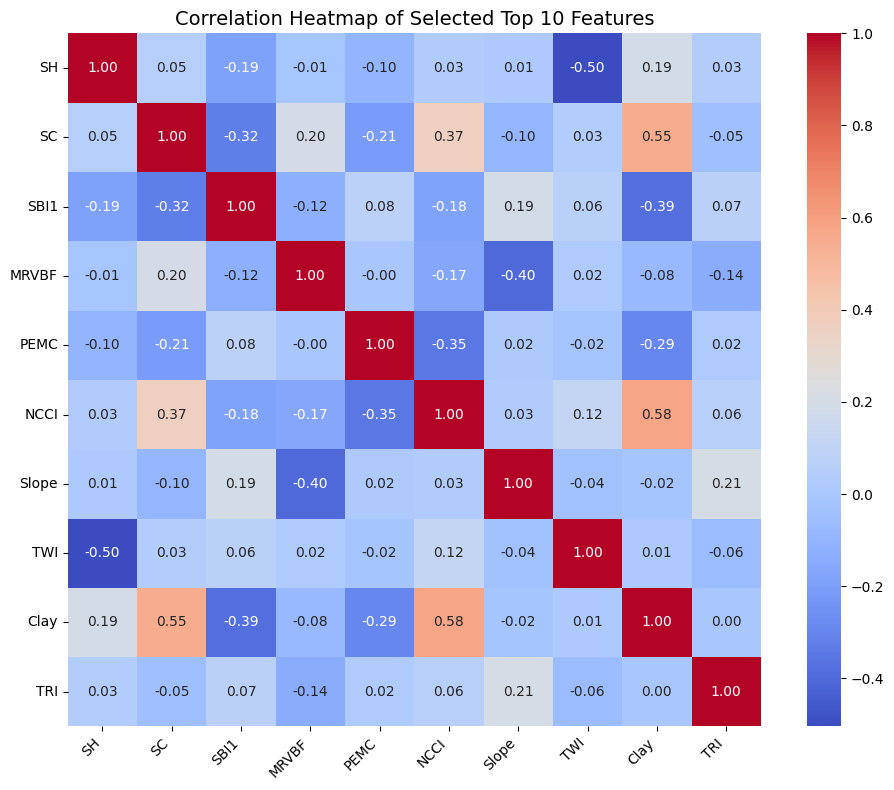

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load the dataset ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")

# === Define long to short name mapping (only for 10 selected features) ===
feature_map = {
    'Standarized_Height': 'SH',
    'gNASGO_SC': 'SC',
    'Senti_BI_1': 'SBI1',
    'MRVBF': 'MRVBF',
    'pctearthmc': 'PEMC',
    'ncci3all': 'NCCI',
    'Slope': 'Slope',
    'TWI': 'TWI',
    'Clay_polaris': 'Clay',
    'Terrain_Ruggedness_Index': 'TRI'
}

# === Select and rename the 10 features ===
df_corr = df[list(feature_map.keys())].dropna()
df_corr.rename(columns=feature_map, inplace=True)

# === Compute correlation matrix ===
corr_matrix = df_corr.corr()

# === Plot heatmap ===
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Selected Top 10 Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


TEST

🔍 Features used for prediction:
 - Standarized_Height
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - pctearthmc
 - ncci3all
 - Slope
 - TWI
 - Clay_polaris
 - Terrain_Ruggedness_Index

📊 Test Set Metrics (Stacked Model):
MAE:  0.710
RMSE: 0.981
R²:   0.57
MBE:  0.143


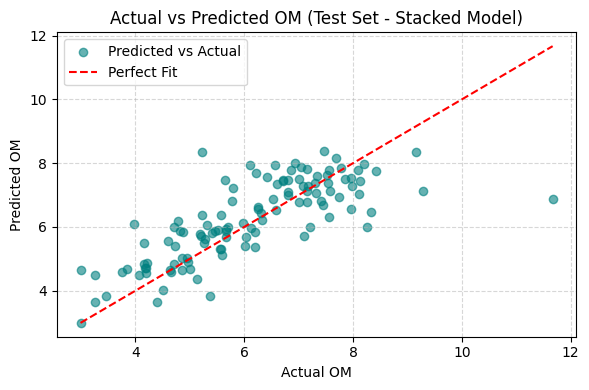

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")  # 📝 update path if needed
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")  # 🧠 Stacked model
scaler = joblib.load("/content/scaler_selected_features.pkl")       # 📏 Scaler for selected features
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")  # ✅ Selected features

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

print("\n📊 Test Set Metrics (Stacked Model):")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.2f}")
print(f"MBE:  {mbe:.3f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
plt.title("Actual vs Predicted OM (Test Set - Stacked Model)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Step 8 (Optional): Save Predictions to CSV ===
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv("stacked_model_test_predictions.csv", index=False)


TEST

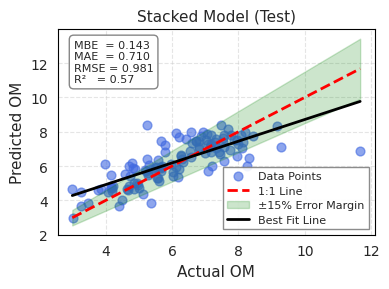

In [47]:
# === Step 6: Plot ===
plt.figure(figsize=(4, 3))
ax = plt.gca()
ax.grid(True, linestyle='--', alpha=0.5)

# Thin black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# Scatter — MATCHED with training plot
plt.scatter(x_sorted, y_sorted, color='royalblue', alpha=0.6, s=40, label='Data Points')

# 1:1 Line
plt.plot([x_sorted.min(), x_sorted.max()], [x_sorted.min(), x_sorted.max()],
         color='red', linestyle='--', linewidth=2, label='1:1 Line')

# ±15% Error Band
plt.fill_between(x_sorted, lower, upper, color='green', alpha=0.2, label='±15% Error Margin')

# Regression Line
plt.plot(x_sorted, y_fit_sorted, color='black', linewidth=2, label='Best Fit Line')

# Metrics Box
metrics_text = (
    f"MBE  = {mbe:.3f}\n"
    f"MAE  = {mae:.3f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"R²   = {r2:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.95)
)

# Labels and Title
plt.xlabel("Actual OM", fontsize=11)
plt.ylabel("Predicted OM", fontsize=11)
plt.title("Stacked Model (Test)", fontsize=11)

# Legend
plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=0.9,
    edgecolor='gray',
    labelspacing=0.4
)

plt.tight_layout()
plt.show()


Feature?Importance

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 31
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

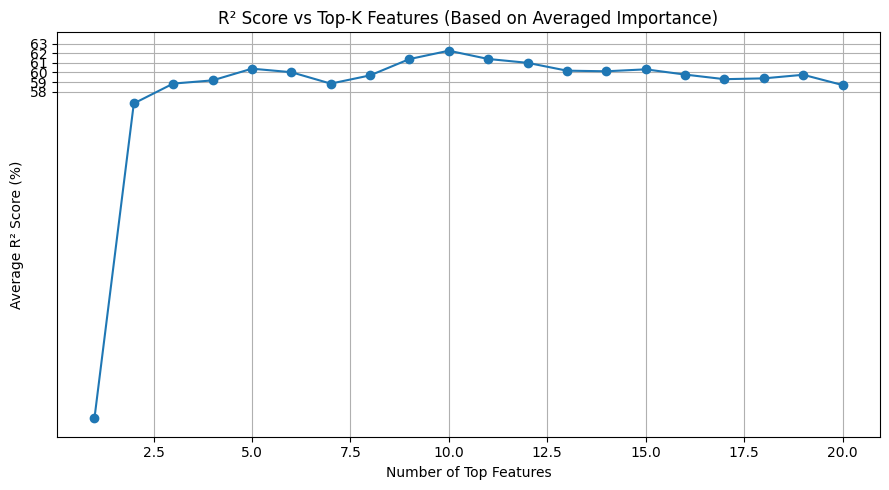

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

# === Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Get average feature importance ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Base models (excluding KNN for importance)
models = [
    RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42),
    XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42),
    LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    BayesianRidge()
]

importances = []
for model in models:
    model.fit(X_scaled_full, y)
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        coef /= np.sum(coef)
        importances.append(coef)

avg_importance = np.mean(importances, axis=0)

# === Rank features ===
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# === Evaluate R² for top 1 to N features ===
max_k = 20  # Top 1 to 20 features
results = []

for k in range(1, max_k + 1):
    selected_features = importance_df['Feature'].iloc[:k].tolist()
    X_selected = X[selected_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)

    # Define full model
    base_models = [
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)),
        ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)),
        ('et', ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42)),
        ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)),
        ('knn', KNeighborsRegressor(n_neighbors=5)),
        ('bayridge', BayesianRidge())
    ]

    meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

    stack = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True,
        n_jobs=-1
    )

    # 10-fold CV
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    r2_folds = []

    for train_idx, val_idx in kf.split(X_scaled):
        X_t, X_v = X_scaled[train_idx], X_scaled[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        stack.fit(X_t, y_t)
        y_pred = stack.predict(X_v)
        r2_folds.append(r2_score(y_v, y_pred))

    avg_r2 = np.mean(r2_folds)
    results.append(avg_r2 * 100)  # Convert to percentage (e.g., 0.60 -> 60.0)
    print(f"Top {k} Features -> R²: {avg_r2:.4f}")

# === Plot R² vs Top K Features ===
plt.figure(figsize=(9, 5))
plt.plot(range(1, max_k + 1), results, marker='o', linestyle='-')
plt.title("R² Score vs Top-K Features (Based on Averaged Importance)")
plt.xlabel("Number of Top Features")
plt.ylabel("Average R² Score (%)")
plt.yticks(np.arange(58, 64, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


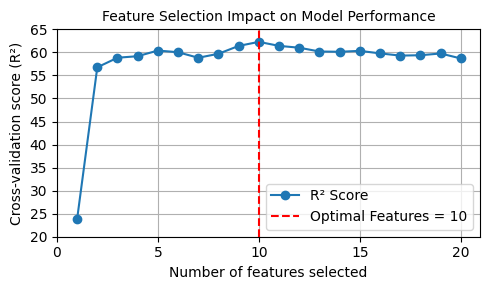

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual R² results you shared (as percentages)
results = [
    23.80, 56.76, 58.84, 59.17, 60.40,
    60.03, 58.83, 59.70, 61.40, 62.28,
    61.41, 61.01, 60.19, 60.13, 60.33,
    59.78, 59.30, 59.38, 59.76, 58.68
]

# Number of features
feature_counts = list(range(1, len(results) + 1))

# Find optimal number of features
optimal_idx = int(np.argmax(results))
optimal_k = feature_counts[optimal_idx]
optimal_r2 = results[optimal_idx]

# Plot
plt.figure(figsize=(5, 3))
plt.plot(feature_counts, results, marker='o', linestyle='-', label='R² Score')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal Features = {optimal_k}')
plt.title("Feature Selection Impact on Model Performance", fontsize=10)
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (R²)")
plt.xticks([0, 5, 10, 15, 20])
plt.yticks(np.arange(20, 70, 5))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 10
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

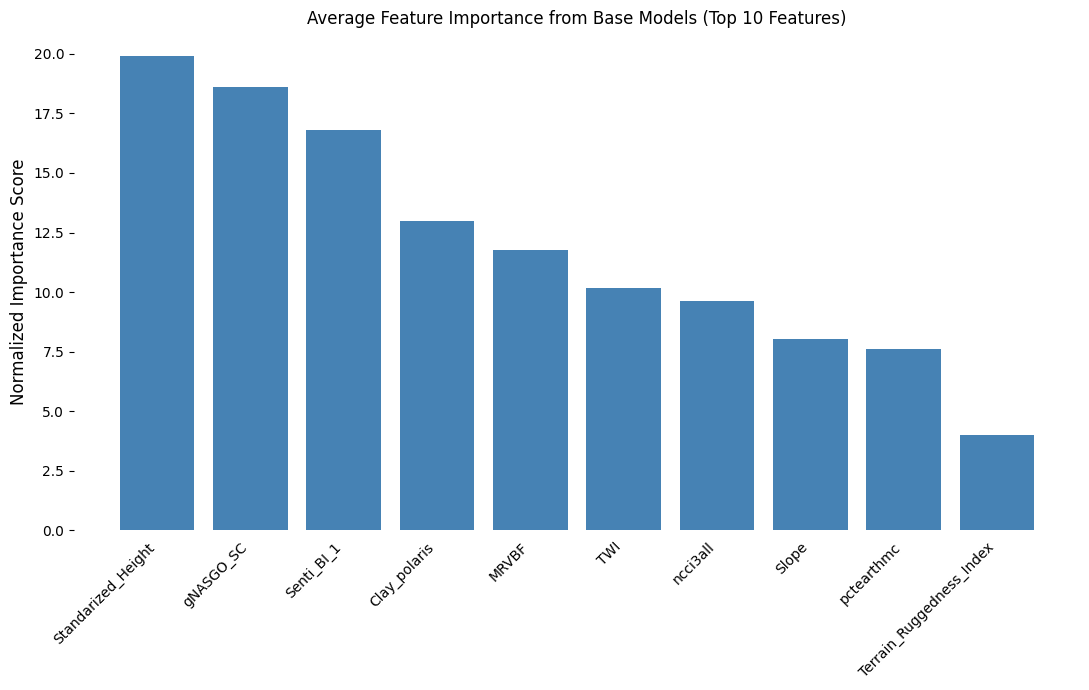

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Use top 10 selected features (already done)
X_top10 = X[selected_features]
scaler_top10 = StandardScaler()
X_top10_scaled = scaler_top10.fit_transform(X_top10)

# Step 2: Reuse already-defined base models
base_models_dict = {
    'rf': rf,
    'ada': ada,
    'gbr': gbr,
    'et': et,
    'xgb': xgb,
    'lgbm': lgbm,
    'bayridge': bayridge,
    # 'knn' excluded since no importances
}

importances = []

# Step 3: Fit each base model on top 10 features and collect importances
for name, model in base_models_dict.items():
    model.fit(X_top10_scaled, y)

    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        coef /= np.sum(coef)  # Normalize coefficients
        importances.append(coef)

# Step 4: Average importance across models
avg_importance_top10 = np.mean(importances, axis=0)

# Step 5: Create DataFrame
importance_df_avg = pd.DataFrame({
    'Feature': selected_features,
    'Avg_Importance': avg_importance_top10
}).sort_values(by='Avg_Importance', ascending=False)

# Step 6: Plot
plt.figure(figsize=(11, 7))
plt.bar(importance_df_avg['Feature'], importance_df_avg['Avg_Importance'], color='steelblue')

plt.title("Average Feature Importance from Base Models (Top 10 Features)", fontsize=12)
plt.ylabel("Normalized Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', right=False)

# Remove frame
plt.grid(False)
plt.gca().set_facecolor('white')
for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


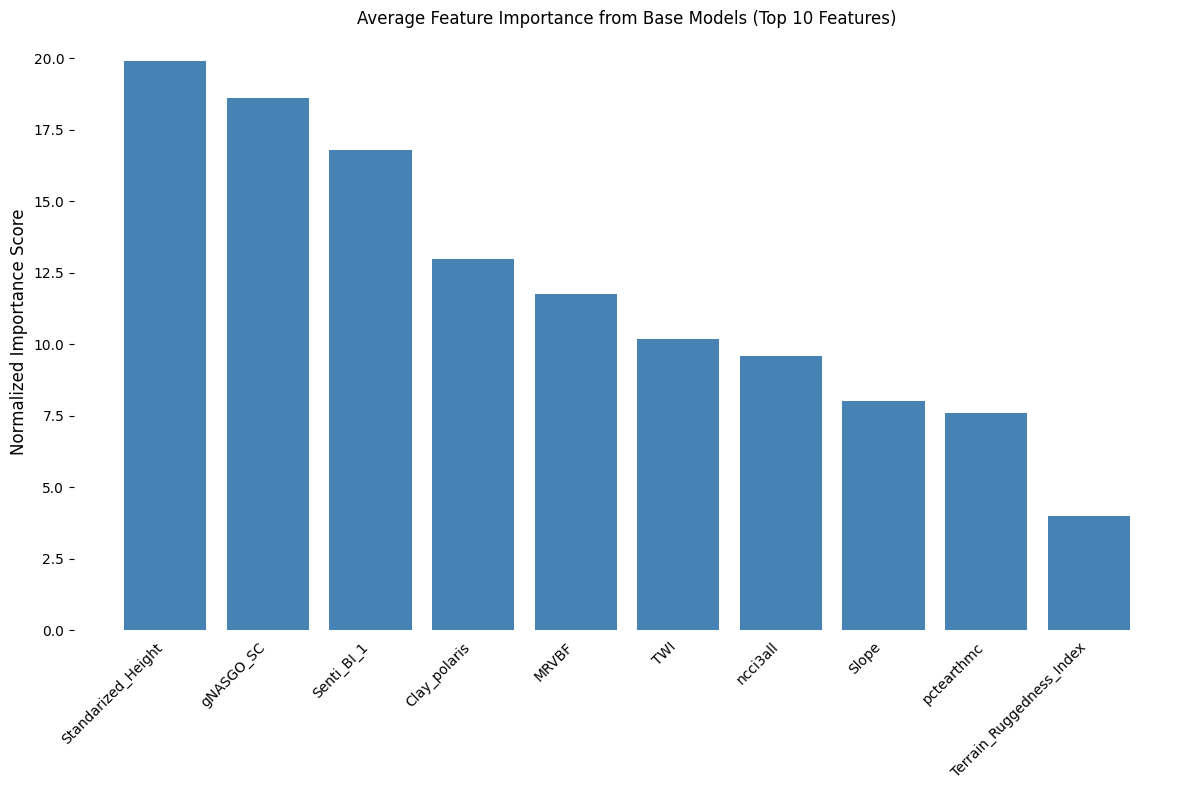

In [ ]:
# Step 6: Plot
plt.figure(figsize=(12, 8))
plt.bar(importance_df_avg['Feature'], importance_df_avg['Avg_Importance'], color='steelblue')

plt.title("Average Feature Importance from Base Models (Top 10 Features)", fontsize=12)
plt.ylabel("Normalized Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', right=False)

# Remove frame
plt.grid(False)
plt.gca().set_facecolor('white')
for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


📊 Per Fold Metrics:
Fold 1: MBE=-0.2243, MAE=1.2330, RMSE=1.6647, R²=0.5899
Fold 2: MBE=-0.2815, MAE=1.6607, RMSE=2.1806, R²=0.0894
Fold 3: MBE=0.5226, MAE=0.9616, RMSE=1.2264, R²=0.5648
Fold 4: MBE=0.0079, MAE=1.7217, RMSE=2.2738, R²=-0.0357
Fold 5: MBE=-0.3309, MAE=1.4788, RMSE=1.9295, R²=0.4189
Fold 6: MBE=0.1998, MAE=1.4374, RMSE=1.9174, R²=0.2740
Fold 7: MBE=-0.4562, MAE=1.1972, RMSE=1.6625, R²=0.4096
Fold 8: MBE=-0.1718, MAE=1.4950, RMSE=2.0344, R²=0.3341
Fold 9: MBE=-0.1082, MAE=1.3746, RMSE=1.8292, R²=0.3894
Fold 10: MBE=0.1222, MAE=1.4281, RMSE=1.9267, R²=0.4776

📌 Average 10-Fold Metrics:
MBE:  -0.0720
MAE:  1.3988
RMSE: 1.8645
R²:   0.3512


/tmp/ipython-input-19-496177780.py:90: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


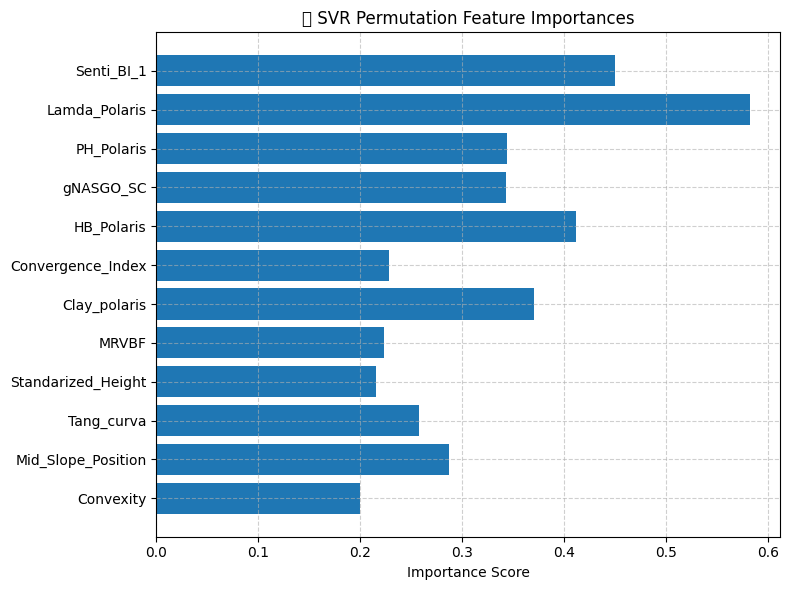

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base SVR ===
svr_base = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_base.fit(X_scaled, y)
perm_importance = permutation_importance(svr_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final SVR Model ===
best_svr = SVR(kernel='rbf', C=100, epsilon=0.1)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_svr.fit(X_t, y_t)
    y_pred = best_svr.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_svr, "best_svr_model.pkl")
joblib.dump(scaler, "scaler_svr.pkl")
joblib.dump(selected_features, "selected_features_svr.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
svr_final_importance = permutation_importance(best_svr, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = svr_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 SVR Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


TEST

🔍 Features used for prediction:
 - Senti_BI_1
 - Lamda_Polaris
 - PH_Polaris
 - gNASGO_SC
 - HB_Polaris
 - Convergence_Index
 - Clay_polaris
 - MRVBF
 - Standarized_Height
 - Tang_curva
 - Mid_Slope_Position
 - Convexity

📊 Test Set Metrics (Stacked Model):
MAE:  1.4280
RMSE: 1.9625
R²:   -0.7016
MBE:  -0.2321


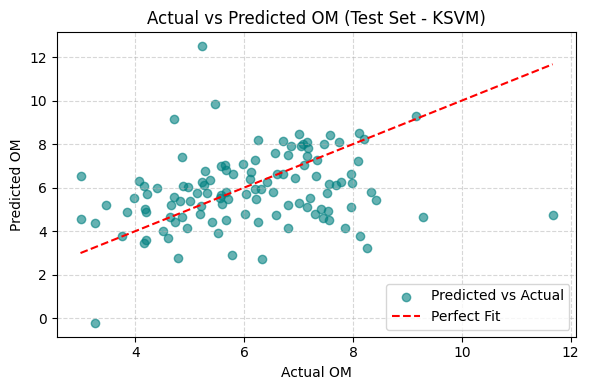

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")  # 📝 update path if needed
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("/content/best_svr_model.pkl")  # 🧠 Stacked model
scaler = joblib.load("/content/scaler_svr.pkl")       # 📏 Scaler for selected features
selected_features = joblib.load("/content/selected_features_svr.pkl")  # ✅ Selected features

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

print("\n📊 Test Set Metrics (Stacked Model):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
plt.title("Actual vs Predicted OM (Test Set - KSVM)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Step 8 (Optional): Save Predictions to CSV ===
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv("stacked_model_test_predictions.csv", index=False)
